# **SYNTHETIC DATA GENERATION (SDG) PIPELINE**
---

> *The synthetic data generation (SDG) is a process to reproduce and using original data as input to generate an artificial dataset. This dataset is processed by constructing its statistical model using several techniques. In this studies, diffusion-based methods will applied.*

---



---

# **Notebook Overview**

This notebook presents the end-to-end Synthetic Data Generation (SDG) pipeline used in this research.  
The pipeline focuses on generating statistically reliable synthetic datasets and validating their quality before downstream usage.

---

## **Objectives**

- Generate synthetic datasets from transactional and customer data  
- Preserve statistical and behavioural patterns of the original data  
- Ensure privacy-preserving data sharing  
- Validate synthetic data using both conceptual and tool-based evaluation  

---

## **Pipeline Overview**

The SDG pipeline consists of four main components:

1. Data Preparation  
2. Exploratory Data Analysis (EDA)  
3. Synthetic Data Generation  
4. Synthetic Data Validation  

---

## **Table of Contents**

### 1. Data Preparation
### 2. Synthetic Data Generation
### 3. Synthetic Data Validation
#### 3.1 SynthEval (Conceptual Evaluation)
#### 3.2 SynthCity Metrics (Tool-based Evaluation)
---

<div style="background-color: #eefbff; border-left: 6px solid #007bff; padding: 15px; border-radius: 5px; font-family: sans-serif;">
    <strong style="color: #0056b3; font-size: 1.1em;">💡 Note:</strong><br>
    <p style="margin-top: 5px; color: #333;">
       <b><i><p>This notebook focuses only on the SDG pipeline</p>
           <p>Exploratory Data Analysis for the dataset have been done in the AS-IS process.</p>
           <p>Governance simulations (AS-IS vs TO-BE) are handled in separate notebooks</p>
           <p>The validated synthetic dataset produced here will be used as input for downstream analysis</p></i></b>
    </p>
</div>

## **Research Methodology Framework (SDG Pipeline)**

This section focuses specifically on the Synthetic Data Generation (SDG) pipeline, which serves as the foundational component of the overall research methodology.

The SDG pipeline is structured into two sequential stages:

- Synthetic Data Generation  
- Synthetic Data Validation  

This structure ensures that the generated synthetic dataset is statistically reliable before being used in downstream analytical and governance simulations.

---

## **Stage 1: Synthetic Data Generation**

The first stage focuses on generating synthetic datasets from the original datasets (`customers` and `transactions`) using deep generative models implemented in the SynthCity framework.

The objective is to produce a synthetic dataset that preserves the statistical properties and behavioural patterns of the original data while preventing direct disclosure of sensitive information.

Prior to model training, preprocessing is applied to prepare the transactional and customer datasets.

A diffusion-based model (DDPM) from SynthCity is used to learn the underlying data distribution and generate synthetic datasets.

---

## **Stage 2: Synthetic Data Validation**

Before being used in downstream processes, the synthetic dataset is evaluated using **SynthEval** and **built-in evaluation metrics provided by SynthCity**.

### **1. Evaluation using SynthEval (Conceptual Framework)**

SynthEval is used to assess synthetic data quality across three key dimensions:

#### **Fidelity**  
Measures how well the synthetic dataset reproduces the statistical structure of the real dataset:
- Distribution similarity  
- Correlation preservation  
- Distance-based statistical tests  

#### **Utility**  
Measures whether the synthetic dataset can support downstream analytical tasks, such as:
- Train on Synthetic, Test on Real (TSTR)

#### **Privacy**  
Measures the risk of sensitive information disclosure:
- Membership inference risk  
- Nearest-neighbour disclosure risk  

---

### **2. Evaluation using SynthCity Built-in Metrics (Tool-based Evaluation)**

In addition to SynthEval, built-in evaluation metrics provided by SynthCity are applied to complement the validation process.

These metrics focus on:

- **Sanity checks**  
  *(e.g., missing values, data consistency)*  

- **Statistical similarity**  
  *(distribution alignment between real and synthetic data)*  

- **Machine learning performance**  
  *(ability to distinguish or replicate real data patterns)*  

- **Privacy-related indicators**  
  *(risk of data memorisation or leakage)*  

---

<div style="background-color: #eefbff; border-left: 6px solid #007bff; padding: 15px; border-radius: 5px; font-family: sans-serif;">
    <strong style="color: #0056b3; font-size: 1.1em;">💡 Note:</strong><br>
    <p style="margin-top: 5px; color: #333;">
       <b><i>Only synthetic datasets that demonstrate acceptable performance across both SynthEval dimensions and SynthCity evaluation metrics are considered valid for downstream use.</i></b>
    </p>
</div>

---
## ***Summary of the SDG Pipeline***

The overall research workflow can be summarized as follows:

---

## ***References***

1. SynthCity: https://github.com/vanderschaarlab/synthcity  
2. SynthEval: https://github.com/schneiderkamplab/syntheval

---
# **SECTION 1 — Load Data**

*Exploratory Data Analysis for the dataset have been done in the AS-IS process.*

---
## **1.1 — Customers**

## **Data Dictionary for Customers Table**

| Field           | Description                                                              |
| --------------- | ------------------------------------------------------------------------ |
| bank_reg_dt     | Date the customer was registered / activated in the bank                 |
| birth_dt        | Birth date for private customers; legal registration date for corporates |
| client_id       | Primary key for the customer master record                               |       |
| gender_cd       | M / F / U (unknown or undisclosed)                                       |
| group_head_flg  | **Codes:** 1 = parent company (group head), 0 = child / subsidiary       |
| lang_pref       | Interface / communication language code (e.g., EN, ET, LV, LT, RU, DE)   |
| postal_code     | ZIP / Postal code of the customer’s address                              |
| segment         | High-level segment: Corporate / SME / Private                            |
| type_cd         | **Codes:** C = Corporate, H = Private (household / retail)               |


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import torch
from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader
from synthcity.metrics import Metrics
from syntheval import SynthEval

warnings.filterwarnings('ignore')

C:\Users\ASUS\anaconda3\envs\synth_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [2]:
customers = pd.read_csv(r"data/customers_sampled.csv")

## **Customer Base Profile**

---

### **Basic Data Information Customers**

In [3]:
print(f'\n\033[1m ~~~~~ CUSTOMER DATA SANITY CHECK ~~~~~ \033[0m\n')

# Dimensions & Info
print(f'\033[1m--- DIMENSIONS ---\033[0m\n{customers.shape}\n')

print("\033[1m--- DATA INFO & TYPES ---\033[0m")
customers.info()
print()

# Missing Values
print(f"\033[1m--- MISSING VALUES ---\033[0m\n{customers.isnull().sum()}\n")

# Duplicates
print(f"\033[1m--- DUPLICATE CLIENT_ID ---\033[0m\n{customers.duplicated(subset=['client_id']).sum()}\n")

# Statistical Summary
print("\033[1m--- STATISTICAL DESCRIPTION ---\033[0m")
display(customers.describe(include='all'))

# Display dataset
print("\n\033[1m--- CUSTOMER DATASET ---\n\033[0m")
display(customers.head())


 ~~~~~ CUSTOMER DATA SANITY CHECK ~~~~~ 

--- DIMENSIONS ---
(100, 9)

--- DATA INFO & TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   client_id       100 non-null    object
 1   type_cd         100 non-null    object
 2   segment         100 non-null    object
 3   group_head_flg  100 non-null    object
 4   birth_dt        100 non-null    object
 5   gender_cd       100 non-null    object
 6   lang_pref       100 non-null    object
 7   postal_code     100 non-null    int64 
 8   bank_reg_dt     100 non-null    object
dtypes: int64(1), object(8)
memory usage: 7.2+ KB

--- MISSING VALUES ---
client_id         0
type_cd           0
segment           0
group_head_flg    0
birth_dt          0
gender_cd         0
lang_pref         0
postal_code       0
bank_reg_dt       0
dtype: int64

--- DUPLICATE CLIENT_ID ---
0

--- STATISTICAL 

,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt
count,100,100,100,100,100,100,100,100.000000,100
unique,100,1,1,1,100,2,3,NaN,98
top,CUST000150,H,Private,Parent,1980-09-14,F,EE,NaN,2024-09-26
freq,1,100,100,100,1,55,75,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44947.660000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29383.659289,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10066.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12661.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46663.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74991.250000,NaN



--- CUSTOMER DATASET ---



,client_id,type_cd,segment,group_head_flg,birth_dt,gender_cd,lang_pref,postal_code,bank_reg_dt
0,CUST000150,H,Private,Parent,1980-09-14,F,EE,11795,2013-10-09
1,CUST000189,H,Private,Parent,2003-06-19,F,RU,44041,2023-02-18
2,CUST000272,H,Private,Parent,1977-12-27,F,RU,11957,2023-05-16
3,CUST000295,H,Private,Parent,1986-06-30,F,RU,10379,2021-05-20
4,CUST000336,H,Private,Parent,2000-02-25,M,RU,13311,2023-08-04


---
## **1.2 — Transactions**

## **Data Dictionary for Transactions Table**

| Field             | Description                                                        |
| ----------------- | ------------------------------------------------------------------ |
| client_id         | Foreign key to `customers.client_id`                               |
| date              | Value / booking date of the transaction (bank ledger date)         |
| time              | Time component for the booking entry                               |
| txn_id            | Unique transaction / journal identifier                            |
| channel           | Origin channel: online, mobile, card, branch, atm                  |
| d_c               | **Codes:** D = debit (money leaves); C = credit (money enters)     |
| trx_ccy           | Original transaction currency                                      |
| amount_eur        | Transaction amount converted to EUR                                |
| amount_orig       | Amount in the original transaction currency                        |
| acct_iban         | IBAN of the customer’s account                                     |
| counterparty_iban | IBAN of the other party                                            |
| mcc               | 4-digit merchant category code (ISO 18245); card transactions only |
| merchant_country  | Country of the merchant (card transactions only)                   |


In [4]:
transactions = pd.read_csv(r"data/transactions_sampled.csv")

## **Transaction Base Profile**

---

### **Basic Data Information transaction**

In [5]:
print(f'\n\033[1m ~~~~~ TRANSACTION DATA SANITY CHECK ~~~~~ \033[0m\n')

# Dimensions & Info
print(f'\033[1m--- DIMENSIONS ---\033[0m\n{transactions.shape}\n')

print("\033[1m--- DATA INFO & TYPES ---\033[0m")
transactions.info()
print()

# Missing Values
print(f"\033[1m--- MISSING VALUES ---\033[0m\n{transactions.isnull().sum()}\n")

# Duplicates
print(f"\033[1m--- DUPLICATE CLIENT_ID ---\033[0m\n{transactions.duplicated(subset=['client_id']).sum()}\n")

# Statistical Summary
print("\033[1m--- STATISTICAL DESCRIPTION ---\033[0m")
display(transactions.describe(include='all'))

# Display dataset
print("\n\033[1m--- TRANSACTION DATASET ---\n\033[0m")
display(transactions.head())


 ~~~~~ TRANSACTION DATA SANITY CHECK ~~~~~ 

--- DIMENSIONS ---
(16797, 13)

--- DATA INFO & TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16797 entries, 0 to 16796
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   client_id          16797 non-null  object 
 1   date               16797 non-null  object 
 2   time               16797 non-null  object 
 3   txn_id             16797 non-null  object 
 4   channel            16797 non-null  object 
 5   d_c                16797 non-null  object 
 6   trx_ccy            16797 non-null  object 
 7   amount_eur         16797 non-null  float64
 8   amount_orig        16797 non-null  float64
 9   acct_iban          16797 non-null  object 
 10  counterparty_iban  16797 non-null  object 
 11  mcc                9855 non-null   float64
 12  merchant_country   16797 non-null  object 
dtypes: float64(3), object(10)
memory usage: 1.7+ MB

--- MISSING V

,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
count,16797,16797,16797,16797,16797,16797,16797,16797.000000,16797.000000,16797,16797,9855.000000,16797
unique,100,366,14309,16797,5,2,9,NaN,NaN,142,4112,NaN,17
top,CUST007049,2024-11-18,18:55:39,TX00021919,card,D,EUR,NaN,NaN,ACC_XJ27DNVWMRNKLCDTXTDNDGGC,CP_Z77UW3O3C3Q5VUFKDXQTASEI,NaN,EE
freq,676,145,5,1,9855,14859,16355,NaN,NaN,565,607,NaN,15115
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.284148,175.795686,NaN,NaN,5550.568645,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,448.664465,534.771937,NaN,NaN,619.663207,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.820000,1.820000,NaN,NaN,4111.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.650000,20.000000,NaN,NaN,5411.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.060000,40.280000,NaN,NaN,5651.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.780000,92.440000,NaN,NaN,5816.000000,NaN



--- TRANSACTION DATASET ---



,client_id,date,time,txn_id,channel,d_c,trx_ccy,amount_eur,amount_orig,acct_iban,counterparty_iban,mcc,merchant_country
0,CUST000150,2024-01-25,12:19:22,TX00021919,online,C,EUR,1485.08,1485.08,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_DYWYZMQLCVPL4AFGW2VOZXKL,NaN,EE
1,CUST000150,2024-01-12,18:24:35,TX00021920,online,D,EUR,75.08,75.08,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_NGUYAMUC7YSPV7GGRUX7X6GW,NaN,EE
2,CUST000150,2024-01-16,16:32:33,TX00021921,online,D,EUR,13.22,13.22,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_G2LGX3ZXFVOVH4DVLDLV4R5C,NaN,EE
3,CUST000150,2024-01-22,18:50:18,TX00021922,card,D,EUR,11.05,11.05,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_7FOUQYUKQPL55N4U3PZ5S3RT,5816.0,EE
4,CUST000150,2024-01-18,15:13:12,TX00021923,online,D,EUR,16.07,16.07,ACC_6COGFV4MWLXAH2GNYWGWXJZF,CP_RVMJ22MF25IKELEIFZEPSHJO,NaN,EE


---
# **SECTION 2 — Synthetic Data Generation Pipeline (SDG)**

**Outputs:**  
- `synthetic_customers.csv`  
- `synthetic_transactions.csv`  

---

## **Why This Architecture?**

In the **AS-IS process**, the `customer_day` dataset (monitoring data containing ratios, baselines, severity levels, and flags such as `auto_red_flag`) is derived from raw transactional data by IT/Data Operations.

These features are governed by **deterministic mathematical relationships**, for example:

```
daily_total / baseline_total = ratio_value
ratio_value > threshold      = severity
severity triggered           = auto_red_flag
```

## **Problem with Direct Synthesis**

If the `customer_day` dataset is directly synthesized, the diffusion model (DDPM) would be required to learn these deterministic dependencies implicitly.

However, diffusion models are designed to learn **statistical distributions**, not exact functional rules.

As a result, synthetic data generated at this level may exhibit:

- Broken relationships between dependent variables  
- Inconsistent severity or flag logic  
- Loss of operational validity  

---

## **Proposed Solution Architecture**

To address this limitation, the SDG pipeline is designed to synthesize only **raw-level datasets**, while preserving deterministic logic externally.

**Solution Architecture:**
```(this notebook): Synthesize RAW data only
    customers_sampled.csv  -> synthetic_customers.csv     (demographics)
    transactions_sampled   -> synthetic_transactions.csv  (raw transactions)
```

The monitoring logic is then applied **after synthetic data generation** in the TO-BE Simulation, ensuring consistency of:
```
    -> aggregate per client/day
    -> compute baselines, ratios, severities, auto_red_flag
    -> synthetic_customer_day.csv  (operationally consistent)

```

> Separate **stochastic learning (SDG)** from **deterministic business logic**

This ensures that:

- Synthetic data preserves realistic statistical properties  
- Derived features remain logically consistent  
- Operational rules are correctly enforced  


---
## **2.1 — Global Configuration**

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('\n~~~~~ Environment Info ~~~~~\n')
print(f'Device     : {device}')

print()
print('\n~~~~~ DDPM Configuration ~~~~~\n')
print('Model      : SynthCity DDPM (Tabular Diffusion)')
print('Setup      : Default configuration (no hyperparameter tuning)')
print('Purpose    : Baseline synthetic data generation')


~~~~~ Environment Info ~~~~~

Device     : cuda


~~~~~ DDPM Configuration ~~~~~

Model      : SynthCity DDPM (Tabular Diffusion)
Setup      : Default configuration (no hyperparameter tuning)
Purpose    : Baseline synthetic data generation


---
## **Shared Utility Functions**

*this utility functions will used together for ``customers`` dataset and ``transactions`` to synthisize data*

## **Synthetic Data: Inverse Transform to Original Scale**

*Reverses RobustScaler to restore original data scale.*

In [7]:
# Reverses Scaler to restore original data scale.
def inverse_transform(df, scaler, scale_cols):
    
    # avoid modifying the original synthetic dataframe
    df = df.copy()

    if scale_cols:
        df[scale_cols] = scaler.inverse_transform(df[scale_cols])
    
    print(f'\n\033[1m----- INVERSE TRANSFORM: -----\n\033[0m')
    for col in scale_cols:
        print(f'  {col:25s}: min={df[col].min():.3f}, max={df[col].max():.3f}')
    print(f'NaN check: {df.isnull().sum().sum()} NaN')
    return df

## **Distribution Comparation: Real vs Synthetic Data**

*Compares mean/std between real and synthetic*

In [8]:
# Compares mean/std between real and synthetic. GOOD/OK/POOR status.
# GOOD (<10%) / OK (<30%) / POOR comparison of means.

def compare_distributions(real_df, synth_df, label=''):
    shared = [c for c in real_df.select_dtypes(include=np.number).columns
              if c in synth_df.columns]
    
    print(f"\033[1m-- DISTRIBUTION STATISTICAL COMPARISON {label}: --\033[0m")
    print(f'  {"Column":28s} {"Real Mean":>10} {"Syn Mean":>10} {"Diff%":>8} {"Status":>8}')
    print('  ' + '-' * 70)
    
    for col in shared:
        rm   = real_df[col].mean()
        sm   = synth_df[col].mean()
        diff = abs(rm - sm) / (abs(rm) + 1e-10) * 100
        stat = 'GOOD' if diff < 10 else ('OK' if diff < 30 else 'POOR')
        print(f'  {col:28s} {rm:>10.3f} {sm:>10.3f} {diff:>7.1f}% {stat:>8}')

## **Synthetic Data Evaluation Function: Synthcity Build-in**

*This Synthetic Data Evaluation is built-in function in SynthCity.*

---

***this guit-in function Covers: ``sanity, fidelity (stats), utility (performance), privacy``.***

Run SynthCity built-in evaluation on real vs synthetic data.

Parameters:
- loader_real : SynthCity GenericDataLoader for real data
- synth_df    : synthetic dataframe with matching schema
- label       : optional experiment label

Returns:
- score dataframe

Metrics used in this study:

**1. Sanity Check:**
* ***common_rows_proportion***: The proportion of rows in the real dataset leaked in the synthetic dataset (0: no common rows leaked; 1: all the rows in the real dataset are leaked).
* ***data_mismatch***: Average number of columns with datatype(object, real, int) mismatch between the real and synthetic data (0: no datatype mismatch; 1: complete data type mismatch between the datasets).

**2. Statistical Test:**
* ***jensenshannon_dist***: The Jensen-Shannon distance (metric) between two probability arrays. This is the square root of the Jensen-Shannon divergence (0: The distributions are the same; 1: The distributions are totally different).
* ***ks_test***: The Kolmogorov-Smirnov test (0: the distributions are totally different; 1: the distributions are identical).

**3. Performance/Synthetic Data Quality Test:**
* ***performance.linear***: Train a Linear classifier/regressor/survival model on real data(gt) and the synthetic data and evaluate the performance on test data. (0: worst performance; 1: ideal performance).

**2. Privacy Metrics:**
* ***delta_presence***: TThe maximum re-identification risk for the real dataset from the synthetic dataset. (0: no risk).
* ***identifiability_score***: The re-identification score on the real dataset from the synthetic dataset.

*Note: ``synth_df`` must be all-numeric (no string columns).*

In [9]:
# SynthCity built-in evaluation: sanity, fidelity, utility, privacy.

def run_synthcity_eval(loader_real, synth_df, label=''):
    
    # Convert the synthetic dataframe into a SynthCity-compatible loader
    loader_synth = GenericDataLoader(synth_df)
    
    print(f'\n\033[1m----- SYNTHCITY EVAL: {label} -----\033[0m')
    
    # Run evaluation across 4 dimensions: sanity, stats, utility, privacy
    score = Metrics.evaluate(
        X_gt     = loader_real,   # Ground‑truth (real) data loader
        X_syn    = loader_synth,    # Synthetic data loader
        metrics  = {
            'sanity'     : ['common_rows_proportion', 'data_mismatch'], 
            'stats'      : ['jensenshannon_dist', 'ks_test'],            # Fidelity / distribution similarity
            'performance': ['linear_model'],                              # Downstream ML utility
            'privacy'    : ['delta_presence', 'identifiability_score'],  # Privacy risk indicators
        }
    )
    display(score)
    return score


*Reference: https://github.com/vanderschaarlab/synthcity?tab=readme-ov-file#zap-evaluation-metrics*

## **Synthetic Data Evaluation Function: SynthEval**

*This Synthetic Data Evaluation using SynthEval*

---

Run SynthEval evaluation on real vs synthetic data.
Parameters:
- real_df      : real dataframe
- synth_df     : synthetic dataframe
- cat_cols     : list of categorical columns
- label        : optional label for logging
- target_col   : optional target column for ML utility metrics
- holdout_df   : optional holdout dataframe
- drop_id_cols : optional identifier columns to exclude

Returns:
- SynthEval results

In [10]:
def run_syntheval(real_df, synth_df, cat_cols, label='', target_col=None, holdout_df=None, drop_id_cols=None):
    if drop_id_cols is None:
        drop_id_cols = []

    # Drop datetime columns from evaluation
    drop_dt_cols = [
        c for c in real_df.columns
        if pd.api.types.is_datetime64_any_dtype(real_df[c])
    ]

    # Keep only shared, comparable columns
    shared = [
        c for c in real_df.columns
        if c in synth_df.columns
        and c not in drop_dt_cols
        and c not in drop_id_cols
    ]

    # Keep only valid categorical columns موجود in shared schema
    valid_cats = [c for c in cat_cols if c in shared]

    real_eval = real_df[shared].copy()
    synth_eval = synth_df[shared].copy()

    # Cast categorical columns to string for SynthEval stability
    for df in [real_eval, synth_eval]:
        for col in valid_cats:
            df[col] = df[col].astype(str)

    # Fill missing numeric values
    for df in [real_eval, synth_eval]:
        for col in df.select_dtypes(include=np.number).columns:
            df[col] = df[col].fillna(df[col].median())

    # Optional holdout
    holdout_eval = None
    if holdout_df is not None:
        holdout_shared = [c for c in shared if c in holdout_df.columns]
        holdout_eval = holdout_df[holdout_shared].copy()
        holdout_eval = holdout_eval[real_eval.columns]

        for col in valid_cats:
            if col in holdout_eval.columns:
                holdout_eval[col] = holdout_eval[col].astype(str)

        for col in holdout_eval.select_dtypes(include=np.number).columns:
            holdout_eval[col] = holdout_eval[col].fillna(holdout_eval[col].median())

    print(f'\n\033[1m----- SYNTHEVAL: {label} -----\033[0m')
    print(f'Shape: real={real_eval.shape}, synthetic={synth_eval.shape}')
    print(f'Categorical columns: {valid_cats}')
    print(f'Dropped ID columns : {drop_id_cols}')

    evaluator = SynthEval(
        real_eval,
        holdout_dataframe=holdout_eval,
        cat_cols=valid_cats
    )

    results = evaluator.evaluate(
        synth_eval,
        presets_file='full_eval',
        target_col=target_col
    )

    return results

---
## **Global Pseudo Customer Key Map**

To ensure consistency across datasets, a global `pseudo_customer_key` is generated from the original `client_id`.

This mapping is constructed once from the `customers` dataset and reused across both customer and transaction pipelines.

### **Purpose**

Both `customers` and `transactions` datasets share the same `client_id`.  
However, directly using this identifier would expose sensitive information and violate privacy constraints.

At the same time, removing the identifier entirely would break the ability to:

- link customer and transaction data  
- perform cross-table analysis  
- simulate realistic downstream processes  

To address this, a **pseudo identifier mapping** is introduced.

*Built once from `customers.csv` — used in both pipelines to ensure `synthetic_customers.pseudo_customer_key == synthetic_transactions.pseudo_customer_key`.*

***This enables cross-layer join in the TO-BE simulation without any PII.***

In [11]:
# Build pseudo_customer_key: Apply global pseudo_customer_key

# handle `client_id`  for both pipeline

all_clients    = sorted(customers['client_id'].unique())
PSEUDO_KEY_MAP = {
    cid: f'SYN_C_{i:06d}'
    for i, cid in enumerate(all_clients, start=1)
}

print(f'Global pseudo key map: {len(PSEUDO_KEY_MAP):,} clients')
print(f'\nSample: {list(PSEUDO_KEY_MAP.items())[:3]}')

print(f'\n\n[!] This map is NOT saved in any output CSV.')
print(f'    Re-identification requires IT/DataOps controlled access.')


Global pseudo key map: 100 clients

Sample: [('CUST000150', 'SYN_C_000001'), ('CUST000189', 'SYN_C_000002'), ('CUST000272', 'SYN_C_000003')]


[!] This map is NOT saved in any output CSV.
    Re-identification requires IT/DataOps controlled access.


---
# **PIPELINE 1: CUSTOMER SYNTHETIC DATA**

### **Goal**
*Synthesize customer-level demographic attributes for use in the TO-BE monitoring pipeline.*

This pipeline is designed as the cleanest possible input for DDPM:
- no monitoring-derived columns  
- no deterministic ratios or flags  
- no time-series dependencies  
- only static customer attributes 

### **Features synthesized**
The following features are used as inputs for the generative model:
- `gender_cd`  
- `lang_pref`  
- `birth_dt` (or derived `age`)  
- `bank_reg_dt` (or derived `tenure_years`)  
- `postal_code`  

These features contain sufficient variability and are relevant for customer profiling.


### **Identifier handling**
- `client_id` is not used directly in modeling  
- it is replaced using a deterministic `pseudo_customer_key` mapping  

This ensures:
- consistent linkage across datasets  
- no exposure of original identifiers


### **Features excluded from synthesis**
The following features are excluded from the generative modeling process due to **zero variance**:

- `type_cd`  
- `segment`  
- `group_head_flg`  

Since these variables have constant values across all records, they do not contribute to distribution learning.

### **Post-processing**
Excluded features are reintroduced after synthetic data generation as constant values to preserve schema consistency.

### **What is NOT here (by design)**
Monitoring-related features (e.g., baselines, ratios, severities, flags) are not generated in this pipeline.

These variables are computed deterministically in `TOBE_Simulation.ipynb` based on synthetic transaction data.

### Key Design Principle

> Separate stochastic learning (SDG) from deterministic business logic  
> and exclude non-informative features from generative modeling


---
---

## **P1.1 — Customer Data: Data Preprocessing**

Prepares ``customers.csv`` for synthesis.

This step:
- derives `age` and `tenure_years` from date columns
- converts date-based attributes into DDPM-friendly numeric features
- label encodes selected categorical variables (`gender_cd`, `lang_pref`)
- excludes zero-variance columns
- assigns a deterministic `pseudo_customer_key`
- removes direct identifiers and unsupported raw datetime fields
- excludes `postal_code` because of its high-cardinality and non-essential for the initial synthesis setup


In [12]:
def preprocess_customers(df, reference_date='2026-01-01'):
    ref = pd.Timestamp(reference_date)

    # avoid modifying the original dataframe
    df  = df.copy()

    # Drop zero-variance columns and high cardinality column
    drop_cols = ['type_cd', 'segment', 'group_head_flg', 'postal_code']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    print(f'Dropped zero-variance and high-cardinality columns: {[c for c in drop_cols]}')

    # Derive age and tenure (meaningful for DDPM)
    df['birth_dt']    = pd.to_datetime(df['birth_dt'],    errors='coerce')
    df['bank_reg_dt'] = pd.to_datetime(df['bank_reg_dt'], errors='coerce')
    df['age']          = ((ref - df['birth_dt']).dt.days    / 365.25).round(1)
    df['tenure_years'] = ((ref - df['bank_reg_dt']).dt.days / 365.25).round(1)

    if df['age'].isna().any():
        print(f'[WARN] age contains {df["age"].isna().sum()} NaN values')
    
    if df['tenure_years'].isna().any():
        print(f'[WARN] tenure_years contains {df["tenure_years"].isna().sum()} NaN values')

    # Drop original datetime — DDPM cannot handle datetime type
    df.drop(columns=['birth_dt', 'bank_reg_dt'], inplace=True)
    print(f'Derived: age (min={df["age"].min():.1f}, max={df["age"].max():.1f})')
    print(f'Derived: tenure_years (min={df["tenure_years"].min():.1f}, max={df["tenure_years"].max():.1f})')

    # Label encode categoricals — store encoders for later reverse
    encoders = {}
    for col in ['gender_cd', 'lang_pref']:
        if col in df.columns:
            le            = LabelEncoder()
            df[col]       = le.fit_transform(df[col].astype(str))
            encoders[col] = le
            print(f'Label-encoded {col}: {dict(enumerate(le.classes_))}')

    # Assign pseudo_customer_key (uses global map)
    df['pseudo_customer_key'] = df['client_id'].map(PSEUDO_KEY_MAP)
    n_unmapped = df['pseudo_customer_key'].isna().sum()
    if n_unmapped > 0:
        print(f'[WARN] {n_unmapped} rows unmapped in PSEUDO_KEY_MAP')

    #drop real client
    df.drop(columns=['client_id'], inplace=True)

    print(f'\n\033[1m ----- CUSTOMER PREPROCESSING RESULT -----\033[0m')
    print(f'Shape   : {df.shape}')
    print(f'Columns : {df.columns.tolist()}')
    print(f'NaN     : {df.isnull().sum().sum()}')
    
    return df, encoders


In [13]:
# run preprocess function

customer_df, cust_encoders = preprocess_customers(customers)
print(f'\n\033[1m CUSTOMER DATASET - AFTER PREPROCESSING\033[0m')
display(customer_df.head())

Dropped zero-variance and high-cardinality columns: ['type_cd', 'segment', 'group_head_flg', 'postal_code']
Derived: age (min=19.1, max=81.9)
Derived: tenure_years (min=1.0, max=15.4)
Label-encoded gender_cd: {0: 'F', 1: 'M'}
Label-encoded lang_pref: {0: 'EE', 1: 'EN', 2: 'RU'}

 ----- CUSTOMER PREPROCESSING RESULT -----
Shape   : (100, 5)
Columns : ['gender_cd', 'lang_pref', 'age', 'tenure_years', 'pseudo_customer_key']
NaN     : 0

 CUSTOMER DATASET - AFTER PREPROCESSING


,gender_cd,lang_pref,age,tenure_years,pseudo_customer_key
0,0,0,45.3,12.2,SYN_C_000001
1,0,2,22.5,2.9,SYN_C_000002
2,0,2,48.0,2.6,SYN_C_000003
3,0,2,39.5,4.6,SYN_C_000004
4,1,2,25.9,2.4,SYN_C_000005


*reference: https://pandas.pydata.org/docs/reference/api/pandas.Categorical.codes.html*

***Result Intepretation:***

The resulting dataset contains only statistically meaningful and non-deterministic features. This ensures that the generative model learns realistic behavioural distributions without being affected by:
- deterministic dependencies
- high-cardinality identifiers
- non-learnable constant features

## **P1.2 — Customer Data: Normalization - StandardScaler**

*Normalizes will apply for customer data; however, due to its distribution stability, StandardScaler is used for customer demographic features, while RobustScaler is applied to transaction data to handle skewness and outliers.


In [14]:
print(f'\n\033[1m ----- SANITY CHECK BEFORE NORMALIZATION -----\033[0m')
print(f' Shape   : {customer_df.shape}')
print(f' Columns : {customer_df.columns.tolist()}')
print(f' NaN     : {customer_df.isnull().sum().sum()} ')
print(f'\n ----- Data Types: -----\n{customer_df.dtypes} ')


 ----- SANITY CHECK BEFORE NORMALIZATION -----
 Shape   : (100, 5)
 Columns : ['gender_cd', 'lang_pref', 'age', 'tenure_years', 'pseudo_customer_key']
 NaN     : 0 

 ----- Data Types: -----
gender_cd                int32
lang_pref                int32
age                    float64
tenure_years           float64
pseudo_customer_key     object
dtype: object 


In [15]:
# RobustScaler on continuous columns. Skip encoded categoricals and key.

def normalize_features_cust(df):
    # avoid modifying the original dataframe
    df = df.copy()
    
    # Columns to scale (continuous only)
    cust_scale_cols = [c for c in ['age', 'tenure_years'] if c in df.columns]
    
    # Columns to skip
    cust_skip_cols  = ['gender_cd', 'lang_pref', 'pseudo_customer_key']
    
    std_scaler = StandardScaler()

    if cust_scale_cols:
        df[cust_scale_cols] = std_scaler.fit_transform(df[cust_scale_cols])

    #print normalization result
    
    print(f'\n\033[1m ----- NORMALIZATION RESULT -----\033[0m')
    
    print(f'Normalized Columns: {cust_scale_cols}')
    print(f'Skipped   : {[c for c in cust_skip_cols if c in df.columns]}')
    
    for col in cust_scale_cols:
        print(f'  {col:20s}: min={df[col].min():.3f}, max={df[col].max():.3f}')
    print(f'NaN check  : {df.isnull().sum().sum()} NaN')
    
    return df, std_scaler, cust_scale_cols  # return scaler for inverse transform 

In [16]:
customer_df_ready, std_scaler, cust_scale_cols = normalize_features_cust(customer_df)

print(f'\n\033[1m ----- FINAL CHECK BEFORE DDPM ----- \033[0m')
print(f'Shape : {customer_df_ready.shape}')
print(f'NaN   : {customer_df_ready.isnull().sum().sum()}  <-- should be 0')
print()
display(customer_df_ready.head())


 ----- NORMALIZATION RESULT -----
Normalized Columns: ['age', 'tenure_years']
Skipped   : ['gender_cd', 'lang_pref', 'pseudo_customer_key']
  age                 : min=-1.818, max=2.865
  tenure_years        : min=-1.298, max=2.481
NaN check  : 0 NaN

 ----- FINAL CHECK BEFORE DDPM ----- 
Shape : (100, 5)
NaN   : 0  <-- should be 0



,gender_cd,lang_pref,age,tenure_years,pseudo_customer_key
0,0,0,0.135853,1.641007,SYN_C_000001
1,0,2,-1.564179,-0.799250,SYN_C_000002
2,0,2,0.337173,-0.877968,SYN_C_000003
3,0,2,-0.296611,-0.353181,SYN_C_000004
4,1,2,-1.310666,-0.930446,SYN_C_000005


***Result Intepretation:***
Negative values in scaled features do not indicate negative meaning, but represent relative position below the mean in standardized space.

## **P1.3 — Customer Data: Synthetic Data Using SynthCity**

---
### **Customer Data: Generate Synthetic Data**

*Synthetic Data Diffusion Model -> DDPM Synthesis*

In [17]:
print(f'\n\033[1m ----- SANITY CHECK BEFORE SYNTHETIC DATA GENERATION -----\033[0m')
print(f' Shape   : {customer_df_ready.shape}')
print(f' Columns : {customer_df_ready.columns.tolist()}')
print(f' NaN     : {customer_df_ready.isnull().sum().sum()} ')
print(f'\n ----- Data Types:-----\n{customer_df_ready.dtypes} ')


 ----- SANITY CHECK BEFORE SYNTHETIC DATA GENERATION -----
 Shape   : (100, 5)
 Columns : ['gender_cd', 'lang_pref', 'age', 'tenure_years', 'pseudo_customer_key']
 NaN     : 0 

 ----- Data Types:-----
gender_cd                int32
lang_pref                int32
age                    float64
tenure_years           float64
pseudo_customer_key     object
dtype: object 


***Important Note:***
The `pseudo customer key` is not treated as a learnable feature, but as a post-generation linkage mechanism to preserve cross-table consistency between synthetic customer and transaction datasets.

In [18]:
# exclude pseudo key
cust_model_input = customer_df_ready.drop(columns=['pseudo_customer_key'])
cust_feature_cols = cust_model_input.columns.tolist()

# Load data
loader_cust = GenericDataLoader(cust_model_input)

print(f'\n\033[1m----- TRAINING DDPM (CUSTOMER DATA) -----\033[0m')

# Get the DDPM plugin with default parameters
model_1 = Plugins().get('ddpm')
model_1.fit(loader_cust)

# print result
print(f'Generating Synthetic Data....')

# Generate synthetic data with ddpm model
cust_synth_df = model_1.generate(count=len(cust_model_input)).dataframe()

# Sanity checking
n_nan = cust_synth_df.isnull().sum().sum()
col_match = list(cust_synth_df.columns) == cust_feature_cols

print(f'\n\033[1m ----- SANITY CHECK ----- \033[0m')
print(f'Synthetic Shape : {cust_synth_df.shape}')
print(f'Original Shape  : {cust_model_input.shape}')
print(f'NaN Count      : {n_nan}')
print(f'Columns Match   : {col_match}')

#print(f'Synthetic Data Shape: {synth_df.shape} | Original Data Shape: {customer_df_ready.shape} |NaN in Sythetic Data: {synth_df.isnull().sum().sum()}')

print(f'\n\033[1m ----- DDPM PIPELINE CUSTOMER DONE -----\033[0m')



----- TRAINING DDPM (CUSTOMER DATA) -----


[2026-05-15T12:50:20.065393+0300][25016][CRITICAL] Error importing TabularGoggle: No module named 'dgl'
[2026-05-15T12:50:20.096410+0300][25016][CRITICAL] module disabled: C:\Users\ASUS\anaconda3\envs\synth_env\lib\site-packages\synthcity\plugins\generic\plugin_goggle.py
Epoch: 100%|████████████████████████████████████████████████████████████| 1000/1000 [00:47<00:00, 21.27it/s, loss=1.15]


Generating Synthetic Data....

 ----- SANITY CHECK ----- 
Synthetic Shape : (100, 4)
Original Shape  : (100, 4)
NaN Count      : 0
Columns Match   : True

 ----- DDPM PIPELINE CUSTOMER DONE -----


### **Interpreting Training Loss in Diffusion Models (DDPM)**

Technically, Denoising Diffusion Probabilistic Models (DDPM) learn by gradually adding noise to the original data and then training a neural network to remove that noise step by step.  

The training **loss** measures the difference between:

- the noise predicted by the model, and  
- the actual noise that was added to the data during the diffusion process.

Therefore, the smaller the loss value, the better the model is at reconstructing the original signal from noisy inputs.

### **Loss Interpretation**

| Loss Value | Interpretation |
|------------|---------------|
| **NaN** | Training has failed. This usually indicates numerical instability or issues in the input data (e.g., NaN values, exploding gradients). |
| **> 5** | The model has not started learning meaningful patterns yet. |
| **1 – 3** | The model is learning normally. This range is common during the early stages of training. |
| **< 1** | The model is approaching convergence and learning useful data representations. |
| **~ 0** | Potential overfitting. The model may be memorizing the training data rather than learning general patterns. |

## **P1.4 — Customer Data: Synthetic Data Post Processing**

*Run global functions such as inverse columns, and distribution comparison; also fix discreate columns*

---

***Step by step:***

*run the functions sequently:*
1. Inverse Transform
2. Fix Discreate
3. Distribution comparison

## **P1.4.1 — Customer Data: Fix Discreate Columns**

*Run function fix discreate columns*

---

To transform result into discreate value, such as:
1. Clips and rounds discrete/binary/ordinal columns back to valid ranges.
2. Convert continuous columns to integer (semantically correct)
3. Reverses label encoding
4. Reconstruct date and time

In [19]:
## Clips and rounds discrete/binary/ordinal columns back to valid ranges.
## continuous columns, reverses label encoding for gender_cd and lang_pref
## Converts age and tenure_years to integer (semantically correct).
## reconstruct birth_dt and bank_reg_dt

def fix_discrete_columns_cust(df, cat_encoders):
    # avoid modifying the original dataframe
    df = df.copy()

    # convert continuous demographic variables back to valid integers
    if 'age' in df.columns:
        df['age'] = df['age'].round().clip(17, 100).astype(int)
    if 'tenure_years' in df.columns:
        df['tenure_years'] = df['tenure_years'].round().clip(0, 30).astype(int)

    # Reverse label encoding
    for col, le in cat_encoders.items():
        if col in df.columns:
            n_cls   = len(le.classes_)
            df[col] = df[col].round().astype(int).clip(0, n_cls - 1)
            df[col] = le.inverse_transform(df[col])

    print('\n\033[1m ----- CUSTOMERS DISCRETE FIXED ----- \033[0m')
    if 'age' in df.columns:
        print(f'  age          : min={df["age"].min()}, max={df["age"].max()}')
    if 'tenure_years' in df.columns:
        print(f'  tenure_years : min={df["tenure_years"].min()}, max={df["tenure_years"].max()}')
    if 'gender_cd' in df.columns:
        print(f'  gender_cd    : {df["gender_cd"].unique().tolist()}')
    if 'lang_pref' in df.columns:
        print(f'  lang_pref    : {df["lang_pref"].unique().tolist()}')

    return df


## **P1.4.2 — Synthetic Customer Data Post Processing: Run Inverse Transform (Baseline Dataset)**

In [20]:
# invers transform: Real Baseline

real_cust_original = inverse_transform(
    cust_model_input,
    std_scaler,
    cust_scale_cols
)
 
print(f'\n\033[1m ----- INVERS TRANSFORM RESULT: REAL BASELINE DATASET ----- \n\033[0m')
display(real_cust_original.head())

print(f'\033[1m----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----\033[0m\nShape: {real_cust_original.shape}')



----- INVERSE TRANSFORM: -----

  age                      : min=19.100, max=81.900
  tenure_years             : min=1.000, max=15.400
NaN check: 0 NaN

 ----- INVERS TRANSFORM RESULT: REAL BASELINE DATASET ----- 



,gender_cd,lang_pref,age,tenure_years
0,0,0,45.3,12.2
1,0,2,22.5,2.9
2,0,2,48.0,2.6
3,0,2,39.5,4.6
4,1,2,25.9,2.4


----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----
Shape: (100, 4)


## **P1.4.3 — Synthetic Customer Data Post Processing: Run Fix Discreate Columns (Baseline Dataset)**

In [21]:
# fix discreate column: Baseline

real_cust_original = fix_discrete_columns_cust(
    real_cust_original, #datset after inverse
    cust_encoders
)


print(f'\n\033[1m ----- FIX DISCREATE COLUMN RESULT: REAL BASELINE DATASET ----- \n\033[0m')
display(real_cust_original.head())

print(f'\033[1m----- DATASET DIMENSION FIX DISCREATE COLUMNS -----\033[0m\nShape: {real_cust_original.shape}')


 ----- CUSTOMERS DISCRETE FIXED ----- 
  age          : min=19, max=82
  tenure_years : min=1, max=15
  gender_cd    : ['F', 'M']
  lang_pref    : ['EE', 'RU', 'EN']

 ----- FIX DISCREATE COLUMN RESULT: REAL BASELINE DATASET ----- 



,gender_cd,lang_pref,age,tenure_years
0,F,EE,45,12
1,F,RU,22,3
2,F,RU,48,3
3,F,RU,40,5
4,M,RU,26,2


----- DATASET DIMENSION FIX DISCREATE COLUMNS -----
Shape: (100, 4)


## **P1.4.4 — Synthetic Customer Data Post Processing: Run All Preprocessing Functions (Synthetic Dataset)**

In [22]:
# Synthetic post-processing

print(f'\n\033[1m ----- POST-PROCESSING SYNTHETIC CUSTOMER DATA -----\033[0m')

# inverse transform data for synthetic data
cust_synth_processed = inverse_transform(
    cust_synth_df,
    std_scaler,
    cust_scale_cols
)

cust_synth_processed = fix_discrete_columns_cust(
    cust_synth_processed,
    cust_encoders
)

print(f'\n\033[1m----- SYNTHETIC CUSTOMER AFTER POST-PROCESSING -----\033[0m')
display(cust_synth_processed.head())
print(f'Shape: {cust_synth_processed.shape}')

# Distribution comparison
compare_distributions(
    real_cust_original,
    cust_synth_processed,
    label='| customers default run'
)


 ----- POST-PROCESSING SYNTHETIC CUSTOMER DATA -----

----- INVERSE TRANSFORM: -----

  age                      : min=19.100, max=81.900
  tenure_years             : min=1.000, max=15.400
NaN check: 0 NaN

 ----- CUSTOMERS DISCRETE FIXED ----- 
  age          : min=19, max=82
  tenure_years : min=1, max=15
  gender_cd    : ['M', 'F']
  lang_pref    : ['EE', 'RU', 'EN']

----- SYNTHETIC CUSTOMER AFTER POST-PROCESSING -----


,gender_cd,lang_pref,age,tenure_years
0,M,EE,82,1
1,F,EE,38,8
2,F,EE,59,4
3,F,EE,36,8
4,F,EE,38,1


Shape: (100, 4)
-- DISTRIBUTION STATISTICAL COMPARISON | customers default run: --
  Column                        Real Mean   Syn Mean    Diff%   Status
  ----------------------------------------------------------------------
  age                              43.460     43.750     0.7%     GOOD
  tenure_years                      5.950      5.460     8.2%     GOOD


## **P1.5 — Customer Data: Synthetic Data Validation**

*Run global functions for synthetic data validation such as SynthCity Built-in function for Evaluation and SynthEval*

---

***Step by step:***

*run the functions sequently:*
1. SynthCity Built-in Function
2. SynthEval

## **P1.5.1 — Synthetic Customer Data Validation: Run SynthCity Built-in Function (Synthetic Customer Dataset)**

*Runs SynthCity’s built‑in evaluation metrics for synthetic data.*

This covers:

- Statistical Fidelity: JS divergence, KS test 
- Privacy:  identifiability, delta presence
- Machine Learning (ML) Utility: linear_model ratio
- Sanity check: data mismatch, common rows, row overlap

In [23]:
cat_cols_cust = ['gender_cd', 'lang_pref']

#load customer dataset: real & synthetic
real_eval_cust = real_cust_original.copy()
synth_eval_cust = cust_synth_processed.copy()

# Re-encode object columns consistently across real + synthetic
for col in real_eval_cust.select_dtypes(include='object').columns:
    combined = pd.concat([
        real_eval_cust[col].astype(str),
        synth_eval_cust[col].astype(str)
    ], axis=0)

    le = LabelEncoder()
    le.fit(combined)

    real_eval_cust[col] = le.transform(real_eval_cust[col].astype(str))
    synth_eval_cust[col] = le.transform(synth_eval_cust[col].astype(str))


# Load real data for evaluation
loader_real_eval_cust = GenericDataLoader(real_eval_cust)

# Run SynthCity evaluation
synthcity_eval_cust = run_synthcity_eval(
    loader_real_eval_cust,
    synth_eval_cust,
    label='Customers — Default Run'
)

# Check metrics availability
print('\n----- Available metrics -----')
print(synthcity_eval_cust.index.tolist())

# Calculate utility ratio
print('\n\033[1m----- Utility Ratio: Customer Default Run -----\033[0m')

if 'performance.linear_model.gt' in synthcity_eval_cust.index:
    gt = synthcity_eval_cust.loc['performance.linear_model.gt', 'mean']
    syn_ood = synthcity_eval_cust.loc['performance.linear_model.syn_ood', 'mean']
    ratio = syn_ood / gt if gt > 0 else 0
    status = 'OK' if ratio > 0.85 else 'NOT OK'
    print(f'  Utility ratio : {ratio:.3f} {status}')
else:
    print('  Utility ratio : N/A (no target column set in loader)')
    print('  -> Add target_column to GenericDataLoader to enable this metric')


----- SYNTHCITY EVAL: Customers — Default Run -----


,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
sanity.data_mismatch.score,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,0.00,minimize
sanity.common_rows_proportion.score,0.110000,0.110000,0.110000,0.0,0.110000,0.0,1,0,0.01,minimize
stats.jensenshannon_dist.marginal,0.009773,0.009773,0.009773,0.0,0.009773,0.0,1,0,0.09,minimize
stats.ks_test.marginal,0.935000,0.935000,0.935000,0.0,0.935000,0.0,1,0,0.02,maximize
performance.linear_model.gt,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,1.43,maximize
performance.linear_model.syn_id,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,1.43,maximize
performance.linear_model.syn_ood,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,1.43,maximize
privacy.identifiability_score.score,0.380000,0.380000,0.380000,0.0,0.380000,0.0,1,0,6.94,minimize
privacy.identifiability_score.score_OC,0.490000,0.490000,0.490000,0.0,0.490000,0.0,1,0,6.94,minimize



----- Available metrics -----
['sanity.data_mismatch.score', 'sanity.common_rows_proportion.score', 'stats.jensenshannon_dist.marginal', 'stats.ks_test.marginal', 'performance.linear_model.gt', 'performance.linear_model.syn_id', 'performance.linear_model.syn_ood', 'privacy.identifiability_score.score', 'privacy.identifiability_score.score_OC']

----- Utility Ratio: Customer Default Run -----
  Utility ratio : 0.000 NOT OK


## **P1.5.2 — Synthetic Customer Data Validation: Run SynthEval (Synthetic Customer Dataset)**

*Runs SynthEval for synthetic data.*

This covers:

- Statistical Fidelity: Hellinger, pMSE, corr diff
- Privacy: NNDR, hitting rate, epsilon
- Machine Learning (ML) Utility: AUROC if target_col is set/available
- MIA: if holdout dataset is set/available


----- SYNTHEVAL: Customer Default Run -----
Shape: real=(100, 4), synthetic=(100, 4)
Categorical columns: ['gender_cd', 'lang_pref']
Dropped ID columns : []
SynthEval: synthetic data read successfully


Syntheval: corr_diff:   6%|███▍                                                         | 1/18 [00:00<00:04,  3.97it/s]

Error: Principal component analysis did not run, analysis class variable not set!


Syntheval: hit_rate:  78%|███████████████████████████████████████████████▍             | 14/18 [00:02<00:00, 11.05it/s]

SynthEval(cls_acc): Analysis target variable not set!


Syntheval: target_col: 100%|███████████████████████████████████████████████████████████| 18/18 [00:02<00:00,  6.82it/s]


Unrecognised keyword: target_col

SynthEval results

Utility metric description                    value   error                                 
+---------------------------------------------------------------+
| Average dimensionwise means diff. (nums) :   0.0198  0.0261   |
| Average confidence interval overlap      :   0.7898  0.1093   |
|   -> # non-overlapping COIs at 95%       :    0               |
|   -> fraction of non-overlapping CIs     :   0.0000           |
| Mixed correlation matrix difference      :   0.1469           |
| Pairwise mutual information difference   :   0.1291           |
| Kolmogorov–Smirnov / Total Variation Distance test            |
|   -> average combined statistic          :   0.0650  0.0250   |
|       -> avg. Kolmogorov–Smirnov dist.   :   0.1000  0.0200   |
|       -> avg. Total Variation Distance   :   0.0300  0.0300   |
|   -> average combined p-value            :   0.7266  0.1333   |
|       -> # significant tests at a=0.05   :    0             

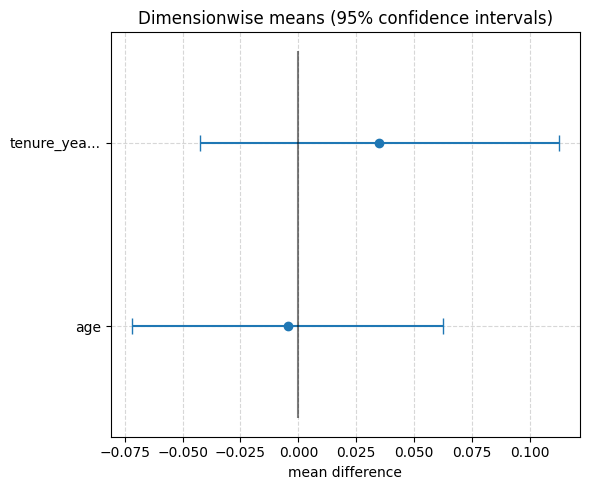

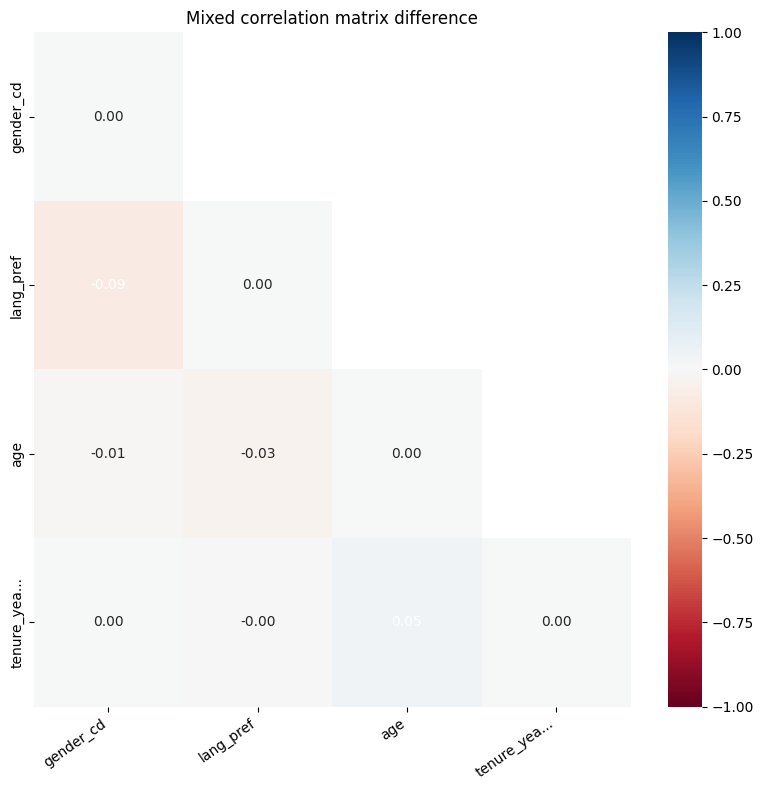

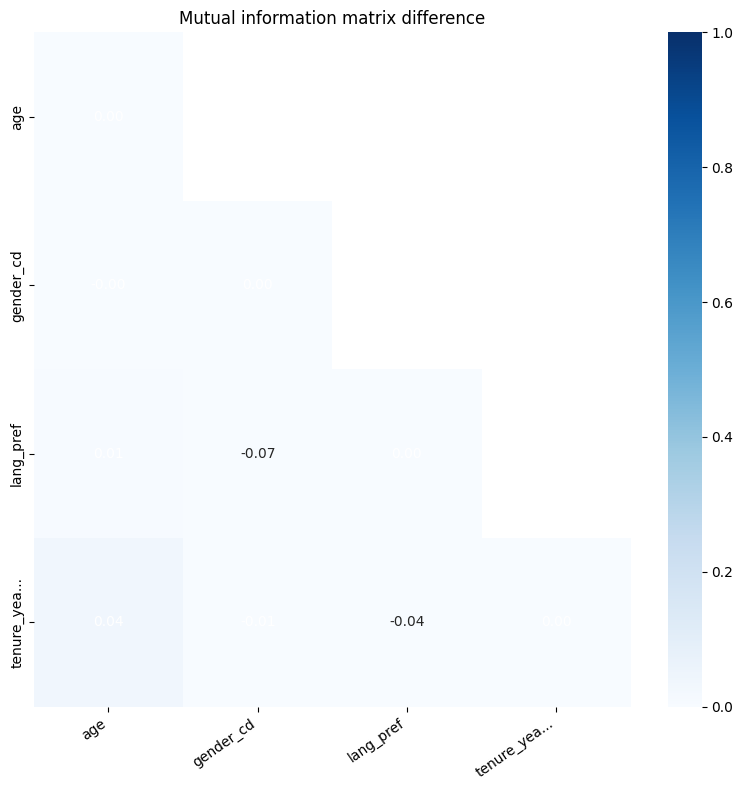

In [24]:
cust_syntheval_results = run_syntheval(
    real_df  =real_cust_original,
    synth_df = cust_synth_processed,
    cat_cols=['gender_cd', 'lang_pref'],
    label='Customer Default Run',
    target_col=None,
    holdout_df=None
)

## **P1.6 — Customer Data: Synthetic Data Result**

*Build final synthetic customer dataset with schema consistency.*

1. `build_final_customer_output()`  
   - Adds synthetic pseudo customer key  
   - Restores zero-variance attributes  
   - Reorders columns to match customer master schema  

2. `add_postal_code_synthetic()`  
   - Adds postal_code using probabilistic sampling based on real data distribution  

> *This attribute is not synthetically learned but probabilistically reconstructed to maintain schema compatibility without exposing sensitive information.*

---


### **P1.6.1 — Customer Data: Synthetic Data Result**

*To build final output for synthetic data*


In [25]:
def build_final_customer_output(df):
    df = df.copy()

    # add back zero-variance columns
    df['type_cd'] = 'H'
    df['segment'] = 'Private'
    df['group_head_flg'] = 'Parent'

    # add synthetic pseudo customer key
    df['pseudo_customer_key'] = [
        f'SYN_C_{i:06d}' for i in range(1, len(df) + 1)
    ]

    # reorder columns
    final_cols = [
        'pseudo_customer_key',
        'type_cd',
        'segment',
        'group_head_flg',
        'gender_cd',
        'lang_pref',
        'age',
        'tenure_years'
    ]

    df = df[final_cols]

    print('\n\033[1m----- FINAL SYNTHETIC CUSTOMER OUTPUT -----\033[0m')
    print(f'Shape   : {df.shape}')
    print(f'Columns : {df.columns.tolist()}')
    print(f'NaN     : {df.isnull().sum().sum()}')

    return df

In [26]:
def add_postal_code_synthetic(df, real_df):
    df = df.copy()

    postal_dist = real_df['postal_code'].value_counts(normalize=True)

    df['postal_code'] = np.random.choice(
        postal_dist.index,
        size=len(df),
        p=postal_dist.values
    )

    return df

In [27]:
cust_synth_final = build_final_customer_output(cust_synth_processed)
cust_synth_final = add_postal_code_synthetic(
    cust_synth_final,   # synthetic dataset
    customers   # raw real customer data, still contains postal_code
)



----- FINAL SYNTHETIC CUSTOMER OUTPUT -----
Shape   : (100, 8)
Columns : ['pseudo_customer_key', 'type_cd', 'segment', 'group_head_flg', 'gender_cd', 'lang_pref', 'age', 'tenure_years']
NaN     : 0


### **P1.6.2 — Customer Data: Real Data Result**

*To re-build final output for real data*


In [28]:
def build_final_customer_baseline(df, original_keys, raw_customers):
    df = df.copy()

    # add zero-variance columns back
    df['type_cd'] = 'H'
    df['segment'] = 'Private'
    df['group_head_flg'] = 'Parent'

    # add original pseudo key
    df['pseudo_customer_key'] = original_keys.values

    # add postal_code from raw real data
    df['postal_code'] = raw_customers['postal_code'].values

    # reorder columns
    final_cols = [
        'pseudo_customer_key',
        'type_cd',
        'segment',
        'group_head_flg',
        'gender_cd',
        'lang_pref',
        'postal_code',
        'age',
        'tenure_years'
    ]

    return df[final_cols]

In [29]:
cust_real_final = build_final_customer_baseline(
    real_cust_original,
    original_keys=customer_df_ready['pseudo_customer_key'],
    raw_customers=customers
)

### **P1.6.3 — Customer Data: Synthetic Data Final Result**

*To save the synthetic data into right path and comparing the output/result to real data (a schema-aligned baseline not raw customer data)*


In [30]:
output_path = r"D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/final datasource/synthetic_customers.csv"
cust_synth_final.to_csv(output_path, index=False)

print('\n\033[1m----- PIPELINE 1 SAVED -----\033[0m')
print(f'Saved to: {output_path}')
print()


print('\n\033[1m[NOTE]\033[0m The real dataset shown here is a schema-aligned baseline. '
      'The original client_id has been replaced with pseudo_customer_key '
      'to ensure structural comparability with the synthetic dataset.')


print('\n\033[1m----- CUSTOMER REAL DATA VS SYNTHETIC DATA -----\n\033[0m')
print('\n 1. CUSTOMER REAL DATA\n')
print(f'Shape: {cust_real_final.shape}')
display(cust_real_final.head())

print('\n 2. CUSTOMER SYNTHETIC DATA\n')
print(f'Shape: {cust_synth_final.shape}')
display(cust_synth_final.head())

print('\n[INFO] Both datasets share identical schema and are ready for downstream TO-BE simulation and cross-table integration.')


----- PIPELINE 1 SAVED -----
Saved to: D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/final datasource/synthetic_customers.csv


[NOTE] The real dataset shown here is a schema-aligned baseline. The original client_id has been replaced with pseudo_customer_key to ensure structural comparability with the synthetic dataset.

----- CUSTOMER REAL DATA VS SYNTHETIC DATA -----


 1. CUSTOMER REAL DATA

Shape: (100, 9)


,pseudo_customer_key,type_cd,segment,group_head_flg,gender_cd,lang_pref,postal_code,age,tenure_years
0,SYN_C_000001,H,Private,Parent,F,EE,11795,45,12
1,SYN_C_000002,H,Private,Parent,F,RU,44041,22,3
2,SYN_C_000003,H,Private,Parent,F,RU,11957,48,3
3,SYN_C_000004,H,Private,Parent,F,RU,10379,40,5
4,SYN_C_000005,H,Private,Parent,M,RU,13311,26,2



 2. CUSTOMER SYNTHETIC DATA

Shape: (100, 9)


,pseudo_customer_key,type_cd,segment,group_head_flg,gender_cd,lang_pref,age,tenure_years,postal_code
0,SYN_C_000001,H,Private,Parent,M,EE,82,1,12537
1,SYN_C_000002,H,Private,Parent,F,EE,38,8,76647
2,SYN_C_000003,H,Private,Parent,F,EE,59,4,12729
3,SYN_C_000004,H,Private,Parent,F,EE,36,8,12357
4,SYN_C_000005,H,Private,Parent,F,EE,38,1,11305



[INFO] Both datasets share identical schema and are ready for downstream TO-BE simulation and cross-table integration.


---
# **PIPELINE 2: TRANSACTION SYNTHETIC DATA**

### **Goal**
*Synthesize raw transaction records for use in TO-BE monitoring pipeline. DDPM learns only statistical distributions of transaction features — no derived monitoring columns.* 

### **Features synthesized**
`amount_eur`, `amount_orig`, `d_c`, `channel`, `trx_ccy`, `merchant_country`, `mcc`

### **What is NOT here (by design)**
Baselines, ratios, severities, auto_red_flag — all computed deterministically in TOBE_Simulation.ipynb.


---
---

## **P2.1 — Transaction Data: Data Preprocessing**

*Drop PII Columns + Assign Pseudo Customer Key*

Removes PII and non-synthesisable identifiers.
* txn_id : unique row ID — synthesising creates meaningless IDs
* acct_iban : direct PII (GDPR Art.4) — bank account identifier
* counterparty_iban: same for receiving account

***Note: client_id kept dropped after assigning customer pseudo key.***



In [31]:
def preprocess_drop_pii(df, pseudo_key_map):

    # avoid modifying the original synthetic dataframe
    df = df.copy()

    # Assign pseudo key BEFORE dropping client_id
    df['pseudo_customer_key'] = df['client_id'].map(pseudo_key_map)
    
    n_unmapped = df['pseudo_customer_key'].isna().sum()
    if n_unmapped > 0:
        print(f'[WARN] {n_unmapped} rows unmapped in PSEUDO_KEY_MAP — dropping')
        df = df[~df['pseudo_customer_key'].isna()]

    print(f'Unique synthetic customer keys: {df["pseudo_customer_key"].nunique():,}')
    print(f'Total rows after mapping: {len(df):,}')

    # define PII columns
    pii_cols = ['txn_id', 'acct_iban', 'counterparty_iban', 'client_id']
    existing = [c for c in pii_cols if c in df.columns]

    # drop PII columns
    df.drop(columns=existing, inplace=True)

    print(f'\n\033[1m ----- PII COLUMNS DROPPED ----- \n\033[0m')
    
    print(f'PII dropped: {existing}')
    print(f'Remaining columns: {df.columns.tolist()}')
    print(f'Shape: {df.shape}')
    
    return df

In [32]:
# run preprocess function

trx_data = preprocess_drop_pii(transactions, PSEUDO_KEY_MAP)

print('\n[CHECK] Key columns presence:')
print(f'Has pseudo_customer_key: {"pseudo_customer_key" in trx_data.columns}')
print(f'Has amount_eur        : {"amount_eur" in trx_data.columns}')
print(f'Has client_id         : {"client_id" in trx_data.columns}')

print(f'\n\033[1m TRANSACTION DATASET - AFTER PREPROCESSING (PII DROP) \033[0m')
display(trx_data.head())

Unique synthetic customer keys: 100
Total rows after mapping: 16,797

 ----- PII COLUMNS DROPPED ----- 

PII dropped: ['txn_id', 'acct_iban', 'counterparty_iban', 'client_id']
Remaining columns: ['date', 'time', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'pseudo_customer_key']
Shape: (16797, 10)

[CHECK] Key columns presence:
Has pseudo_customer_key: True
Has amount_eur        : True
Has client_id         : False

 TRANSACTION DATASET - AFTER PREPROCESSING (PII DROP) 


,date,time,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,pseudo_customer_key
0,2024-01-25,12:19:22,online,C,EUR,1485.08,1485.08,NaN,EE,SYN_C_000001
1,2024-01-12,18:24:35,online,D,EUR,75.08,75.08,NaN,EE,SYN_C_000001
2,2024-01-16,16:32:33,online,D,EUR,13.22,13.22,NaN,EE,SYN_C_000001
3,2024-01-22,18:50:18,card,D,EUR,11.05,11.05,5816.0,EE,SYN_C_000001
4,2024-01-18,15:13:12,online,D,EUR,16.07,16.07,NaN,EE,SYN_C_000001


## **P2.2 — Transaction Data: MCC Missing Flag**

*MCC missing values are treated as **structural missingness**, not random missing data.  
Transactions without MCC (e.g., P2P transfers, ATM withdrawals) are explicitly flagged using `mcc_missing`.*

> Missing MCC values are encoded as `0` for model compatibility, while the `mcc_missing` flag preserves the semantic meaning of missingness.

- MCC ~41% missing (6942 / 16797 rows) — NOT random (P2P/ATM have no MCC).
- Flag BEFORE fill. Restore NaN in post-processing.

Logic:
- Create an indicator column 'mcc_missing' to flag missing MCC entries.
- Fill missing MCC values with numeric placeholder (0).
- Print summary of how many MCC values were originally missing.


In [33]:
def handle_mcc_missing(df):
    
    # avoid modifying the original dataframe
    df = df.copy()

    # If MCC column exists, handle missing-value
    if 'mcc' in df.columns:

        # --- PRE CHECK ---
        n_missing_before = df['mcc'].isna().sum()
        pct_missing = df['mcc'].isna().mean() * 100
        print(f'[BEFORE] mcc missing: {n_missing_before:,} rows ({pct_missing:.1f}%)')
        
        # Binary flag: 1 if MCC is missing, 0 otherwise
        df['mcc_missing'] = df['mcc'].isna().astype(int)

        # Fill with numeric placeholder
        df['mcc'] = df['mcc'].fillna(0).astype(int) # fill Na row with 0

        # count & percentage of missing MCC values
        print(f'mcc_missing: {df["mcc_missing"].sum():,} rows ({df["mcc_missing"].mean()*100:.1f}%)')

    # Final NaN check across entire dataframe
    print(f'NaN check: {df.isnull().sum().sum()} NaN')
    
    return df


In [34]:
trx_data = handle_mcc_missing(trx_data)

print(f'\n\033[1m TRANSACTION DATASET - AFTER PREPROCESSING (HANDLE MCC MISSING) \033[0m')
display(trx_data.head())

[BEFORE] mcc missing: 6,942 rows (41.3%)
mcc_missing: 6,942 rows (41.3%)
NaN check: 0 NaN

 TRANSACTION DATASET - AFTER PREPROCESSING (HANDLE MCC MISSING) 


,date,time,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,pseudo_customer_key,mcc_missing
0,2024-01-25,12:19:22,online,C,EUR,1485.08,1485.08,0,EE,SYN_C_000001,1
1,2024-01-12,18:24:35,online,D,EUR,75.08,75.08,0,EE,SYN_C_000001,1
2,2024-01-16,16:32:33,online,D,EUR,13.22,13.22,0,EE,SYN_C_000001,1
3,2024-01-22,18:50:18,card,D,EUR,11.05,11.05,5816,EE,SYN_C_000001,0
4,2024-01-18,15:13:12,online,D,EUR,16.07,16.07,0,EE,SYN_C_000001,1


## **P2.3 — Transaction Data: Date & Time Encoding**

*Decomposes date into calendar features. Extracts txn_hour from time.*


In [35]:
def encode_date_time_trx(df):
    
    # avoid modifying the original dataframe
    df = df.copy()

    # encode date

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        n_bad_date = df['date'].isna().sum()

        # transform the date form
        df['txn_year'] = df['date'].dt.year
        df['txn_month'] = df['date'].dt.month
        df['day_in_month'] = df['date'].dt.day
        df['weekday_num'] = df['date'].dt.weekday
        df['quarter'] = df['date'].dt.quarter
        df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

        df.drop(columns=['date'], inplace=True)

        print('Date decomposed: txn_year, txn_month, day_in_month, weekday_num, quarter, is_month_end')
        print(f'Invalid date rows: {n_bad_date}')

    if 'time' in df.columns:
        parsed_time = pd.to_datetime(
            df['time'].astype(str),
            format='%H:%M:%S',
            errors='coerce'
        )
        n_bad_time = parsed_time.isna().sum()

        df['txn_hour'] = parsed_time.dt.hour.fillna(-1).astype(int)

        # drop time column
        df.drop(columns=['time'], inplace=True)
        
        print(f'txn_hour range: {df["txn_hour"].min()}–{df["txn_hour"].max()}')
        print(f'Invalid time rows: {n_bad_time}')
        
    print(f'NaN check: {df.isnull().sum().sum()} NaN')
    
    return df

In [36]:
trx_data = encode_date_time_trx(trx_data)

print(f'\n\033[1m TRANSACTION DATASET - AFTER PREPROCESSING (DATE & TIME ENCODING) \033[0m')
display(trx_data.head())

Date decomposed: txn_year, txn_month, day_in_month, weekday_num, quarter, is_month_end
Invalid date rows: 0
txn_hour range: 6–23
Invalid time rows: 0
NaN check: 0 NaN

 TRANSACTION DATASET - AFTER PREPROCESSING (DATE & TIME ENCODING) 


,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,pseudo_customer_key,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,online,C,EUR,1485.08,1485.08,0,EE,SYN_C_000001,1,2024,1,25,3,1,0,12
1,online,D,EUR,75.08,75.08,0,EE,SYN_C_000001,1,2024,1,12,4,1,0,18
2,online,D,EUR,13.22,13.22,0,EE,SYN_C_000001,1,2024,1,16,1,1,0,16
3,card,D,EUR,11.05,11.05,5816,EE,SYN_C_000001,0,2024,1,22,0,1,0,18
4,online,D,EUR,16.07,16.07,0,EE,SYN_C_000001,1,2024,1,18,3,1,0,15


## **P2.4 — Transaction Data: Categorical Encoding + Log1p Transform**

*Due to transaction skewness, log1p tansformation is applied for numerical and categorical transformations for transaction dataset.*

*Steps:*
1. ***`log1p-transform`*** is applied to numerical transaction amount variables (`amount_eur`, `amount_orig`) to reduce right skewness and stabilize variance.
2. ***`Label-encode`*** all object/category columns -> This type of encoding process is suitable because these columns have low cardinality and; one-hot encoding is unnecessary.

*Returns:*
* transformed dataframe
* dictionary of fitted label encoders (useful if inverse transform needed)



In [37]:
print(f'\n\033[1m ----- SANITY CHECK BEFORE ENCODE & TRANSFORM -----\033[0m')
print(f' Shape   : {trx_data.shape}')
print(f' Columns : {trx_data.columns.tolist()}')
print(f' NaN     : {trx_data.isnull().sum().sum()} ')
print(f'\n ----- Data Types:-----\n{trx_data.dtypes} ')


 ----- SANITY CHECK BEFORE ENCODE & TRANSFORM -----
 Shape   : (16797, 16)
 Columns : ['channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'pseudo_customer_key', 'mcc_missing', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']
 NaN     : 0 

 ----- Data Types:-----
channel                 object
d_c                     object
trx_ccy                 object
amount_eur             float64
amount_orig            float64
mcc                      int32
merchant_country        object
pseudo_customer_key     object
mcc_missing              int32
txn_year                 int32
txn_month                int32
day_in_month             int32
weekday_num              int32
quarter                  int32
is_month_end             int32
txn_hour                 int32
dtype: object 


In [38]:
def encode_and_transform_trx(df):
 
    # avoid modifying the original dataframe
    df = df.copy()
    encoders = {}

    # log transform (reduces skewness in transaction amounts)
    for col in ['amount_eur', 'amount_orig']:
        if col in df.columns:
            # Ensure no negative values are passed to log1p
            df[col] = np.log1p(df[col].clip(lower=0))
            print(f'log1p applied: {col}')

    # label encoding for categorical columns
    skip_cols = ['pseudo_customer_key']  # NOT a feature

    cat_cols = [
        c for c in df.select_dtypes(include=['object', 'category']).columns
        if c not in skip_cols
    ]
    
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f'label-encoded {col}: {len(le.classes_)} classes')

    # final sanity check for any remaining NaN
    print(f'\nNaN check: {df.isnull().sum().sum()} NaN')

    return df, encoders

In [39]:
# run the transformation
print('\n\033[1m ----- ENCODING & TRANSFORMS ----- \033[0m')
trx_data, cat_encoders_trx = encode_and_transform_trx(trx_data)
trx_data.head()


 ----- ENCODING & TRANSFORMS ----- 
log1p applied: amount_eur
log1p applied: amount_orig
label-encoded channel: 5 classes
label-encoded d_c: 2 classes
label-encoded trx_ccy: 9 classes
label-encoded merchant_country: 17 classes

NaN check: 0 NaN


,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,pseudo_customer_key,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,4,0,2,7.303897,7.303897,0,3,SYN_C_000001,1,2024,1,25,3,1,0,12
1,4,1,2,4.331785,4.331785,0,3,SYN_C_000001,1,2024,1,12,4,1,0,18
2,4,1,2,2.654649,2.654649,0,3,SYN_C_000001,1,2024,1,16,1,1,0,16
3,2,1,2,2.489065,2.489065,5816,3,SYN_C_000001,0,2024,1,22,0,1,0,18
4,4,1,2,2.837323,2.837323,0,3,SYN_C_000001,1,2024,1,18,3,1,0,15


## **P2.5 — Transaction Data: Normalization - Robus Scaler**

*Normalizes selected numerical and categorical-coded features using RobustScaler.*

***Why RobustScaler:***
- More stable than standard scaling when the data contains outliers.
- Transactional datasets often have heavy tails (amounts, dates, hours, categories).

***What Happens:***
1. Identify columns to scale on continuous columns. Skips binary/ordinal/cluster.
2. Apply RobustScaler to these columns.
3. Print normalization summary + min/max ranges.

In [40]:
print(f'\n\033[1m ----- SANITY CHECK BEFORE NORMALIZATION -----\033[0m')
print(f' Shape   : {trx_data.shape}')
print(f' Columns : {trx_data.columns.tolist()}')
print(f' NaN     : {trx_data.isnull().sum().sum()} ')
print(f'\n ----- Data Types:-----\n{trx_data.dtypes} ')


 ----- SANITY CHECK BEFORE NORMALIZATION -----
 Shape   : (16797, 16)
 Columns : ['channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'pseudo_customer_key', 'mcc_missing', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']
 NaN     : 0 

 ----- Data Types:-----
channel                  int32
d_c                      int32
trx_ccy                  int32
amount_eur             float64
amount_orig            float64
mcc                      int32
merchant_country         int32
pseudo_customer_key     object
mcc_missing              int32
txn_year                 int32
txn_month                int32
day_in_month             int32
weekday_num              int32
quarter                  int32
is_month_end             int32
txn_hour                 int32
dtype: object 


In [41]:
def normalize_features_trx(df):

    # avoid modifying the original dataframe
    df = df.copy()

    ## continuous / temporal numeric columns to scale
    scale_cols_trx = ['amount_eur', 'amount_orig', 'txn_month', 'day_in_month', 'txn_hour']
    scale_cols_trx = [c for c in scale_cols_trx if c in df.columns]

    # columns intentionally not scaled
    skip_cols_trx = [
        'channel', 'd_c', 'trx_ccy', 'merchant_country',
        'mcc', 'mcc_missing', 'weekday_num', 'quarter',
        'is_month_end', 'pseudo_customer_key'
    ]

    # apply RobustScaler
    rbs_scaler = RobustScaler()
    df[scale_cols_trx] = rbs_scaler.fit_transform(df[scale_cols_trx])

    # summary print out
    print("\n\033[1m ----- NORMALIZATION RESULT ----- \033[0m")
    print(f"Normalized : {scale_cols_trx}")
    print(f"Skipped    : {[c for c in skip_cols_trx if c in df.columns]}")


    print("\nRange after scaling:")
    for col in scale_cols_trx:
        print(f"  {col:25s}: min={df[col].min():.3f}, max={df[col].max():.3f}")

    print(f"\nNaN check: {df.isnull().sum().sum()} NaN")

    return df, rbs_scaler, scale_cols_trx

In [42]:
# Run normalization
trx_ready, scaler_trx, scale_cols_trx = normalize_features_trx(trx_data)

# Print to recheck the result
print(f'\n\033[1m ----- FINAL CHECK BEFORE DDPM ----- \033[0m')
print(f'Shape : {trx_ready.shape}')
print(f'NaN   : {trx_ready.isnull().sum().sum()}  <- should be 0')
print(f'\n ----- Columns:-----\n {trx_ready.columns.tolist()}')
print(f'\n ----- Data Types:-----\n{trx_ready.dtypes} ')


 ----- NORMALIZATION RESULT ----- 
Normalized : ['amount_eur', 'amount_orig', 'txn_month', 'day_in_month', 'txn_hour']
Skipped    : ['channel', 'd_c', 'trx_ccy', 'merchant_country', 'mcc', 'mcc_missing', 'weekday_num', 'quarter', 'is_month_end', 'pseudo_customer_key']

Range after scaling:
  amount_eur               : min=-1.834, max=3.539
  amount_orig              : min=-1.798, max=4.248
  txn_month                : min=-1.000, max=0.833
  day_in_month             : min=-1.071, max=1.071
  txn_hour                 : min=-1.500, max=1.333

NaN check: 0 NaN

 ----- FINAL CHECK BEFORE DDPM ----- 
Shape : (16797, 16)
NaN   : 0  <- should be 0

 ----- Columns:-----
 ['channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'pseudo_customer_key', 'mcc_missing', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']

 ----- Data Types:-----
channel                  int32
d_c                      int32
trx_ccy              

## **P2.6 — Transaction Data: Synthetic Data Using SynthCity**
---

### **P2.6.1 — Transaction Data: Split Data to Train and Test Dataset**

The model-ready transaction dataset is split into two subsets:

- **Training set (80%)** → used to train the DDPM model  
- **Holdout set (20%)** → reserved for evaluation  

This separation ensures that synthetic data quality can be assessed on unseen data.

**Train-Holdout:** A portion of historical, labeled data that is held out of the data sets used for training and validating supervised machine learning models


### **Transaction Variable Mapping**

| Stage                  | Evaluation                        | Production                          |
|-----------------------|----------------------------------|-------------------------------------|
| Model Input           | `trx_train_model`               | `trx_full_model_input`              |
| Real (Processed)      | `real_trx_original`             | `real_trx_original_full`            |
| Synthetic (Raw)       | `trx_synth_eval`                | `trx_synth_full`                    |
| Synthetic (Processed) | `trx_synth_eval_processed`      | `trx_synth_full_processed`          |
| Final Output          | —                                | `trx_synth_final`, `trx_real_final` |

> To avoid ambiguity, variables are explicitly separated between evaluation and production pipelines. This ensures that model validation and final data generation are not mixed.

In [43]:
# split data before training

trx_train, trx_holdout = train_test_split(
    trx_ready, 
    test_size = 0.2, 
    random_state = 42
)

# print train data
print(f'\n\033[1m----- Train   : {trx_train.shape} -----\033[0m')

# print holdout
print(f'\n\033[1m----- Holdout   : {trx_holdout.shape} -----\033[0m')



----- Train   : (13437, 16) -----

----- Holdout   : (3360, 16) -----


---
### **P2.6.2 — Transaction Data: Drop `pseudo_customer_key` Before Model Training**

*The `pseudo_customer_key` is retained during preprocessing for linkage purposes,  
but removed before model training to ensure that only meaningful behavioral features are learned.*

This separates:
- **Data representation layer** (with identifiers)
- **Model representation layer** (feature-only input)

---

#### **Why is `pseudo_customer_key` dropped only before model training (not earlier)?**
The `pseudo_customer_key` is intentionally retained throughout the preprocessing pipeline and only removed immediately before training the synthetic data model. This design choice is made to separate **data engineering needs** from **modeling requirements**.

#### **1. Role of `pseudo_customer_key` in the pipeline**
The `pseudo_customer_key` serves as a **linkage identifier**, not as a feature. It enables:
- Consistent joining between synthetic customers and synthetic transactions
- Reconstruction of downstream datasets (e.g., customer-day aggregation)
- Traceability across different processing stages in the TO-BE simulation

Therefore, it must be preserved during preprocessing.

#### **2. Why it must NOT be used in model training**
If included in the model input:
- It acts as a **random identifier with no semantic meaning**
- The model may learn **spurious patterns or memorization**
- It introduces **data leakage risk**, harming generalization
- It violates the principle of learning only from **behavioral and statistical features**

Hence, it must be excluded from the feature space.

#### **3. Why not drop it earlier?**
Dropping it too early would:
- Break the ability to join datasets across pipelines
- Prevent reconstruction of synthetic outputs into usable downstream formats
- Reduce interpretability and traceability during debugging and validation

#### **4. Final design principle**
The pipeline explicitly separates:
- **Data representation layer** (includes identifiers for linkage)
- **Model representation layer** (contains only learnable features)

Thus:
- `pseudo_customer_key` is **kept during preprocessing**
- `pseudo_customer_key` is **dropped only before modeling**

This ensures both:
- **correct model learning behavior**
- **functional integration across the synthetic data pipeline**

---

In [44]:
trx_train_model = trx_train.drop(columns=['pseudo_customer_key'])
trx_holdout_eval = trx_holdout.drop(columns=['pseudo_customer_key'])

print(f'\nTrain model shape     : {trx_train_model.shape}')
print(f'Holdout eval shape      : {trx_holdout_eval.shape}')
print(f'Has pseudo key (train)  : {"pseudo_customer_key" in trx_train_model.columns}')
print(f'Has pseudo key (holdout): {"pseudo_customer_key" in trx_holdout_eval.columns}')


Train model shape     : (13437, 15)
Holdout eval shape      : (3360, 15)
Has pseudo key (train)  : False
Has pseudo key (holdout): False


---
### **P2.6.3 — Transaction Data: Train DDPM on Training Split**

*The DDPM model is trained exclusively on the training split to prevent data leakage.*


In [45]:
# train DDPM only on transaction training split
loader_trx = GenericDataLoader(trx_train_model)  # train DDPM only for train split

print(f'\n\033[1m----- TRAINING DDPM (TRANSACTION DATA) -----\033[0m')

model_trx = Plugins().get('ddpm')
model_trx.fit(loader_trx)

[2026-05-15T12:51:59.078140+0300][25016][CRITICAL] module disabled: C:\Users\ASUS\anaconda3\envs\synth_env\lib\site-packages\synthcity\plugins\generic\plugin_goggle.py



----- TRAINING DDPM (TRANSACTION DATA) -----


Epoch: 100%|███████████████████████████████████████████████████████████| 1000/1000 [15:17<00:00,  1.09it/s, loss=0.738]


### **P2.6.4 — Transaction Data: Generate Synthetic Data (Evaluation Mode)**

*Synthetic data is generated using the trained DDPM model with the same size as the training dataset. This allows fair comparison between real and synthetic distributions.*


In [46]:
print('Generating Synthetic Data (evaluation mode)...')

trx_synth_eval = model_trx.generate(count=len(trx_train_model)).dataframe()

Generating Synthetic Data (evaluation mode)...


---
### **P2.6.5 — Transaction Data: Sanity Check Generate Synthetic Data (Evaluation Mode)** 

*Verify the generated synthetic dataset*

Verify if the synthetic dataset:
* has the same schema as the training input
* contains no missing values
* matches the expected dimensionality


In [47]:
n_nan = trx_synth_eval.isnull().sum().sum()
col_match = list(trx_synth_eval.columns) == list(trx_train_model.columns)

print(f'\n\033[1m----- SANITY CHECK -----\033[0m')
print(f'Synthetic Shape : {trx_synth_eval.shape}')
print(f'Original Shape  : {trx_train_model.shape}')
print(f'NaN Count       : {n_nan}')
print(f'Columns Match   : {col_match}')


----- SANITY CHECK -----
Synthetic Shape : (13437, 15)
Original Shape  : (13437, 15)
NaN Count       : 0
Columns Match   : True


---
### **P2.6.6 — Transaction Data: Final Synthetic Data Generation**

After validating the model in the evaluation phase, the final synthetic dataset is generated.

At this stage, the model may be retrained on the full dataset to maximize data utilization and produce a complete synthetic dataset for downstream TO-BE simulation.

In [48]:
trx_full_model_input = trx_ready.drop(columns=['pseudo_customer_key'])

loader_full = GenericDataLoader(trx_full_model_input)

# Train model on FULL data
model_trx_full = Plugins().get('ddpm')
model_trx_full.fit(loader_full)

# Generate FULL synthetic data
trx_synth_full = model_trx_full.generate(
    count=len(trx_full_model_input)
).dataframe()

[2026-05-15T13:12:26.163399+0300][25016][CRITICAL] module disabled: C:\Users\ASUS\anaconda3\envs\synth_env\lib\site-packages\synthcity\plugins\generic\plugin_goggle.py
Epoch: 100%|███████████████████████████████████████████████████████████| 1000/1000 [14:24<00:00,  1.16it/s, loss=0.744]


## **P2.7 — Transaction Data: Post Processing**

*Run global functions such as inverse columns, and distribution comparison; also fix discreate columns*

This stage restores transaction datasets from model-ready format into interpretable form.

The following transformations are applied sequentially:
1. **Inverse scaling** → `inverse_transform()`
2. **Reverse log transformation** → `expm1`
3. **Discrete and categorical fixing** → `fix_discrete_columns_trx()`

This ensures that real, holdout, and synthetic datasets are all represented in the same format for comparison and evaluation.

---


## **P2.7.1 — Transaction Data: Real Baseline Post-Processing**

The real transaction baseline (training split) is restored into original scale and interpretable format.

> This dataset serves as the primary reference for statistical comparison with synthetic data.

Fixes and restores discrete, categorical, and log-transformed columns after inverse-scaling synthetic or real transaction data.

***Steps:***
1. Clip and round binary/ordinal flags.
2. Clip and restore valid ranges for weekday/quarter/hour/behavioral_cluster.
3. Reverse log1p transformation for amount variables.
4. Reverse LabelEncoder transforms for categorical features.
5. Restore MCC missingness using the mcc_missing flag.

In [49]:
## Clips discrete/binary/ordinal columns, reverses log1p and label encoding, restores mcc NaN.
## Fixes discrete/ordinal fields, reverses log-transformed amounts,
## restores categorical labels, and reconstructs MCC missingness.

def fix_discrete_columns_trx(df, cat_encoders):
    
    # avoid modifying the original dataframe
    df = df.copy()

    # Reverse label encoding for categorical columns
    for col, le in cat_encoders.items():
        if col in df.columns:
            n_cls = len(le.classes_)
            df[col] = df[col].round().astype(int).clip(0, n_cls - 1)
            df[col] = le.inverse_transform(df[col])

    # Fix binary flags
    for col in ['mcc_missing', 'is_month_end']:
        if col in df.columns:
            df[col] = df[col].round().clip(0, 1).astype(int)

    # Fix ordinal / temporal discrete variables
    if 'txn_year' in df.columns:
        df['txn_year'] = df['txn_year'].round().clip(1990, 2030).astype(int)
    if 'txn_month' in df.columns:
        df['txn_month'] = df['txn_month'].round().clip(1, 12).astype(int)
    if 'day_in_month' in df.columns:
        df['day_in_month'] = df['day_in_month'].round().clip(1, 31).astype(int)
    if 'weekday_num' in df.columns:
        df['weekday_num'] = df['weekday_num'].round().clip(0, 6).astype(int)
    if 'quarter' in df.columns:
        df['quarter'] = df['quarter'].round().clip(1, 4).astype(int)
    if 'txn_hour' in df.columns:
        df['txn_hour'] = df['txn_hour'].round().clip(0, 23).astype(int)

    # Calendar-aware correction for day_in_month
    # Prevents invalid combinations such as Feb 30 or Apr 31
    if {'txn_year', 'txn_month', 'day_in_month'}.issubset(df.columns):
        max_days = pd.to_datetime(
            df['txn_year'].astype(int).astype(str) + '-' +
            df['txn_month'].astype(int).astype(str).str.zfill(2) + '-01',
            errors='coerce'
        ).dt.days_in_month

        df['day_in_month'] = df['day_in_month'].clip(lower=1)
        df['day_in_month'] = np.minimum(df['day_in_month'], max_days).astype(int)
    # Restore original MCC NaNs from mcc_missing indicator
    if 'mcc' in df.columns and 'mcc_missing' in df.columns:
        df.loc[df['mcc_missing'] == 1, 'mcc'] = np.nan
        df.drop(columns=['mcc_missing'], inplace=True)
        print("\nRestored mcc NaN from mcc_missing flag.\n")

    # Summary result
    print("\n\033[1m----- DISCRETE COLUMNS FIXED (TRANSACTION) -----\033[0m")

    check_cols = ['txn_year','txn_month', 'day_in_month', 'weekday_num', 'quarter', 'txn_hour', 'is_month_end']
    for col in [c for c in check_cols if c in df.columns]:
        print(f"  {col:25s}: min={df[col].min()}, max={df[col].max()}")

    if 'channel' in df.columns:
        print(f"  channel sample: {df['channel'].unique().tolist()[:5]}")
    if 'd_c' in df.columns:
        print(f"  d_c sample: {df['d_c'].unique().tolist()}")
    if 'trx_ccy' in df.columns:
        print(f"  trx_ccy sample: {df['trx_ccy'].unique().tolist()[:5]}")

    return df

In [50]:
def reverse_log_transform_trx(df):
    
    # avoid modifying the original dataframe
    df = df.copy()

    for col in ['amount_eur', 'amount_orig']:
        if col in df.columns:
            df[col] = np.expm1(df[col]).clip(lower=0).round(2)

    print("\n----- LOG-TRANSFORM REVERSED (TRANSACTION) -----")
    for col in ['amount_eur', 'amount_orig']:
        if col in df.columns:
            print(f"  {col:25s}: min={df[col].min():.2f}, max={df[col].max():.2f}")

    return df

In [51]:
real_trx_original = inverse_transform(trx_full_model_input, scaler_trx, scale_cols_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----\033[0m\nShape: {real_trx_original.shape}')

print(f'\n\033[1m ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')

display(real_trx_original.head())


----- INVERSE TRANSFORM: -----

  amount_eur               : min=1.037, max=8.812
  amount_orig              : min=1.037, max=10.062
  txn_month                : min=1.000, max=12.000
  day_in_month             : min=1.000, max=31.000
  txn_hour                 : min=6.000, max=23.000
NaN check: 0 NaN
----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----
Shape: (16797, 15)

 ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,4,0,2,7.303897,7.303897,0,3,1,2024,1.0,25.0,3,1,0,12.0
1,4,1,2,4.331785,4.331785,0,3,1,2024,1.0,12.0,4,1,0,18.0
2,4,1,2,2.654649,2.654649,0,3,1,2024,1.0,16.0,1,1,0,16.0
3,2,1,2,2.489065,2.489065,5816,3,0,2024,1.0,22.0,0,1,0,18.0
4,4,1,2,2.837323,2.837323,0,3,1,2024,1.0,18.0,3,1,0,15.0


In [52]:
real_trx_original = reverse_log_transform_trx(real_trx_original)

print(f'\033[1m----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----\033[0m\nShape: {real_trx_original.shape}')

print(f'\n\033[1m ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')
display(real_trx_original.head())



----- LOG-TRANSFORM REVERSED (TRANSACTION) -----
  amount_eur               : min=1.82, max=6712.88
  amount_orig              : min=1.82, max=23439.94
----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----
Shape: (16797, 15)

 ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,4,0,2,1485.08,1485.08,0,3,1,2024,1.0,25.0,3,1,0,12.0
1,4,1,2,75.08,75.08,0,3,1,2024,1.0,12.0,4,1,0,18.0
2,4,1,2,13.22,13.22,0,3,1,2024,1.0,16.0,1,1,0,16.0
3,2,1,2,11.05,11.05,5816,3,0,2024,1.0,22.0,0,1,0,18.0
4,4,1,2,16.07,16.07,0,3,1,2024,1.0,18.0,3,1,0,15.0


In [53]:
real_trx_original = fix_discrete_columns_trx(real_trx_original, cat_encoders_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----\033[0m\nShape: {real_trx_original.shape}')

print(f'\n\033[1m ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- \n\033[0m')
display(real_trx_original.head())


Restored mcc NaN from mcc_missing flag.


----- DISCRETE COLUMNS FIXED (TRANSACTION) -----
  txn_year                 : min=2024, max=2024
  txn_month                : min=1, max=12
  day_in_month             : min=1, max=31
  weekday_num              : min=0, max=6
  quarter                  : min=1, max=4
  txn_hour                 : min=6, max=23
  is_month_end             : min=0, max=1
  channel sample: ['online', 'card', 'mobile', 'atm', 'branch']
  d_c sample: ['C', 'D']
  trx_ccy sample: ['EUR', 'NOK', 'SEK', 'GBP', 'TRY']
----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----
Shape: (16797, 14)

 ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,online,C,EUR,1485.08,1485.08,NaN,EE,2024,1,25,3,1,0,12
1,online,D,EUR,75.08,75.08,NaN,EE,2024,1,12,4,1,0,18
2,online,D,EUR,13.22,13.22,NaN,EE,2024,1,16,1,1,0,16
3,card,D,EUR,11.05,11.05,5816.0,EE,2024,1,22,0,1,0,18
4,online,D,EUR,16.07,16.07,NaN,EE,2024,1,18,3,1,0,15


## **P2.7.2 — Transaction Data: Holdout Post-Processing**

The holdout dataset consists of real transaction records not used during DDPM training.

It is post-processed into the same format as the real baseline to ensure compatibility in evaluation.

This dataset is used for:
- Out-of-sample validation
- Privacy-related evaluation (e.g., membership inference)

In [54]:
trx_holdout_processed = inverse_transform(trx_holdout_eval, scaler_trx, scale_cols_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----\033[0m\nShape: {trx_holdout_processed.shape}')

print(f'\n\033[1m ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')
display(trx_holdout_processed.head())



----- INVERSE TRANSFORM: -----

  amount_eur               : min=1.212, max=8.812
  amount_orig              : min=1.212, max=10.062
  txn_month                : min=1.000, max=12.000
  day_in_month             : min=1.000, max=31.000
  txn_hour                 : min=6.000, max=23.000
NaN check: 0 NaN
----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----
Shape: (3360, 15)

 ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
9068,4,1,2,5.645270,5.645270,0,3,1,2024,9.0,8.0,6,3,0,20.0
6729,2,1,2,3.921379,3.921379,5999,3,0,2024,10.0,24.0,3,4,0,13.0
5553,4,0,2,4.488749,4.488749,0,3,1,2024,6.0,7.0,4,2,0,18.0
10373,2,1,2,3.563600,3.563600,5411,3,0,2024,2.0,17.0,5,1,0,19.0
5099,2,1,2,3.039749,3.039749,4814,3,0,2024,1.0,16.0,1,1,0,17.0


In [55]:
trx_holdout_processed = reverse_log_transform_trx(trx_holdout_processed)

print(f'\033[1m----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----\033[0m\nShape: {trx_holdout_processed.shape}')

print(f'\n\033[1m ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')
display(trx_holdout_processed.head())



----- LOG-TRANSFORM REVERSED (TRANSACTION) -----
  amount_eur               : min=2.36, max=6712.88
  amount_orig              : min=2.36, max=23439.94
----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----
Shape: (3360, 15)

 ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
9068,4,1,2,281.95,281.95,0,3,1,2024,9.0,8.0,6,3,0,20.0
6729,2,1,2,49.47,49.47,5999,3,0,2024,10.0,24.0,3,4,0,13.0
5553,4,0,2,88.01,88.01,0,3,1,2024,6.0,7.0,4,2,0,18.0
10373,2,1,2,34.29,34.29,5411,3,0,2024,2.0,17.0,5,1,0,19.0
5099,2,1,2,19.90,19.90,4814,3,0,2024,1.0,16.0,1,1,0,17.0


In [56]:
trx_holdout_processed = fix_discrete_columns_trx(trx_holdout_processed, cat_encoders_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----\033[0m\nShape: {trx_holdout_processed.shape}')

print(f'\n\033[1m ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- \n\033[0m')
display(trx_holdout_processed.head())


Restored mcc NaN from mcc_missing flag.


----- DISCRETE COLUMNS FIXED (TRANSACTION) -----
  txn_year                 : min=2024, max=2024
  txn_month                : min=1, max=12
  day_in_month             : min=1, max=31
  weekday_num              : min=0, max=6
  quarter                  : min=1, max=4
  txn_hour                 : min=6, max=23
  is_month_end             : min=0, max=1
  channel sample: ['online', 'card', 'atm', 'mobile', 'branch']
  d_c sample: ['D', 'C']
  trx_ccy sample: ['EUR', 'SEK', 'NOK', 'USD', 'PLN']
----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----
Shape: (3360, 14)

 ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
9068,online,D,EUR,281.95,281.95,NaN,EE,2024,9,8,6,3,0,20
6729,card,D,EUR,49.47,49.47,5999.0,EE,2024,10,24,3,4,0,13
5553,online,C,EUR,88.01,88.01,NaN,EE,2024,6,7,4,2,0,18
10373,card,D,EUR,34.29,34.29,5411.0,EE,2024,2,17,5,1,0,19
5099,card,D,EUR,19.90,19.90,4814.0,EE,2024,1,16,1,1,0,17


## **P2.7.3 — Transaction Data: Synthetic Evaluation Post-Processing**

The synthetic transaction dataset generated in evaluation mode (`trx_synth_eval`) is restored into original-scale, interpretable format.

This enables direct comparison with the real training baseline and supports downstream validation using holdout data.

In [57]:
trx_synth_eval_processed = inverse_transform(trx_synth_eval, scaler_trx, scale_cols_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----\033[0m\nShape: {trx_synth_eval_processed.shape}')

print(f'\n\033[1m ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_eval_processed.head())



----- INVERSE TRANSFORM: -----

  amount_eur               : min=1.037, max=8.800
  amount_orig              : min=1.037, max=9.662
  txn_month                : min=1.000, max=12.000
  day_in_month             : min=1.000, max=31.000
  txn_hour                 : min=6.000, max=23.000
NaN check: 0 NaN
----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----
Shape: (13437, 15)

 ----- INVERSE TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,4,0,2,2.715003,2.688667,0,3,1,2024,11.0,15.281198,6,4,0,20.0
1,4,1,2,3.065133,3.054147,0,3,1,2024,8.0,16.251164,0,3,0,14.0
2,2,1,2,3.588603,3.614607,5411,3,0,2024,2.0,10.000000,0,1,0,18.0
3,2,1,2,2.621453,2.620229,5812,3,0,2024,12.0,18.000000,1,4,0,17.0
4,2,1,2,3.353240,3.368584,5941,3,0,2024,10.0,11.000000,2,4,0,8.0


In [58]:
trx_synth_eval_processed = reverse_log_transform_trx(trx_synth_eval_processed)

print(f'\033[1m----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----\033[0m\nShape: {trx_synth_eval_processed.shape}')

print(f'\n\033[1m ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_eval_processed.head())



----- LOG-TRANSFORM REVERSED (TRANSACTION) -----
  amount_eur               : min=1.82, max=6632.45
  amount_orig              : min=1.82, max=15705.88
----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----
Shape: (13437, 15)

 ----- REVERSE LOG TRANSFORM: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,4,0,2,14.10,13.71,0,3,1,2024,11.0,15.281198,6,4,0,20.0
1,4,1,2,20.44,20.20,0,3,1,2024,8.0,16.251164,0,3,0,14.0
2,2,1,2,35.18,36.14,5411,3,0,2024,2.0,10.000000,0,1,0,18.0
3,2,1,2,12.76,12.74,5812,3,0,2024,12.0,18.000000,1,4,0,17.0
4,2,1,2,27.60,28.04,5941,3,0,2024,10.0,11.000000,2,4,0,8.0


In [59]:
trx_synth_eval_processed = fix_discrete_columns_trx(trx_synth_eval_processed, cat_encoders_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----\033[0m\nShape: {trx_synth_eval_processed .shape}')

print(f'\n\033[1m ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_eval_processed .head())


Restored mcc NaN from mcc_missing flag.


----- DISCRETE COLUMNS FIXED (TRANSACTION) -----
  txn_year                 : min=2024, max=2024
  txn_month                : min=1, max=12
  day_in_month             : min=1, max=31
  weekday_num              : min=0, max=6
  quarter                  : min=1, max=4
  txn_hour                 : min=6, max=23
  is_month_end             : min=0, max=1
  channel sample: ['online', 'card', 'mobile', 'branch', 'atm']
  d_c sample: ['C', 'D']
  trx_ccy sample: ['EUR', 'USD', 'GBP', 'SEK', 'DKK']
----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----
Shape: (13437, 14)

 ----- FIX DISCRETE COLUMNS: TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,online,C,EUR,14.10,13.71,NaN,EE,2024,11,15,6,4,0,20
1,online,D,EUR,20.44,20.20,NaN,EE,2024,8,16,0,3,0,14
2,card,D,EUR,35.18,36.14,5411.0,EE,2024,2,10,0,1,0,18
3,card,D,EUR,12.76,12.74,5812.0,EE,2024,12,18,1,4,0,17
4,card,D,EUR,27.60,28.04,5941.0,EE,2024,10,11,2,4,0,8


## **P2.7.4 — Transaction Data: Full Synthetic Post-Processing**

The synthetic transaction dataset generated from the DDPM model is restored into original-scale format.

This enables direct comparison with real transaction data.

In [60]:
#trx_synth_eval_processed = inverse_transform(trx_synth_eval, scaler_trx, scale_cols_trx)
trx_synth_full_processed = inverse_transform(trx_synth_full, scaler_trx, scale_cols_trx)


print(f'\033[1m----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----\033[0m\nShape: {trx_synth_full_processed.shape}')

print(f'\n\033[1m ----- INVERSE TRANSFORM: FULL SYNTHETIC TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_full_processed.head())



----- INVERSE TRANSFORM: -----

  amount_eur               : min=1.212, max=8.812
  amount_orig              : min=1.212, max=9.106
  txn_month                : min=1.000, max=12.000
  day_in_month             : min=1.000, max=31.000
  txn_hour                 : min=6.000, max=23.000
NaN check: 0 NaN
----- DATASET DIMENSION AFTER INVERSE TRANSFORM -----
Shape: (16797, 15)

 ----- INVERSE TRANSFORM: FULL SYNTHETIC TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,2,1,2,1.211941,1.211941,7999,0,0,2024,12.0,1.0,3,3,0,23.0
1,2,1,2,2.417548,2.449356,5814,3,0,2024,5.0,18.0,0,2,0,14.0
2,4,0,2,5.975344,5.909535,0,3,1,2024,6.0,23.0,3,2,0,18.0
3,3,0,2,3.133036,3.113903,0,3,1,2024,7.0,18.0,1,3,0,12.0
4,4,0,2,7.825512,8.087477,0,3,1,2024,8.0,21.0,3,3,0,23.0


In [61]:
trx_synth_full_processed = reverse_log_transform_trx(trx_synth_full_processed)

print(f'\033[1m----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----\033[0m\nShape: {trx_synth_full_processed.shape}')

print(f'\n\033[1m ----- REVERSE LOG TRANSFORM: FULL SYNTHETIC TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_full_processed.head())



----- LOG-TRANSFORM REVERSED (TRANSACTION) -----
  amount_eur               : min=2.36, max=6712.88
  amount_orig              : min=2.36, max=9010.25
----- DATASET DIMENSION AFTER REVERSE LOG TRANSFORM -----
Shape: (16797, 15)

 ----- REVERSE LOG TRANSFORM: FULL SYNTHETIC TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,mcc_missing,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,2,1,2,2.36,2.36,7999,0,0,2024,12.0,1.0,3,3,0,23.0
1,2,1,2,10.22,10.58,5814,3,0,2024,5.0,18.0,0,2,0,14.0
2,4,0,2,392.60,367.53,0,3,1,2024,6.0,23.0,3,2,0,18.0
3,3,0,2,21.94,21.51,0,3,1,2024,7.0,18.0,1,3,0,12.0
4,4,0,2,2502.67,3252.47,0,3,1,2024,8.0,21.0,3,3,0,23.0


In [62]:
trx_synth_full_processed = fix_discrete_columns_trx(trx_synth_full_processed, cat_encoders_trx)

print(f'\033[1m----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----\033[0m\nShape: {trx_synth_full_processed.shape}')

print(f'\n\033[1m ----- FIX DISCRETE COLUMNS: FULL SYNTHETIC TRANSACTION DATASET ----- \n\033[0m')
display(trx_synth_full_processed.head())


Restored mcc NaN from mcc_missing flag.


----- DISCRETE COLUMNS FIXED (TRANSACTION) -----
  txn_year                 : min=2024, max=2024
  txn_month                : min=1, max=12
  day_in_month             : min=1, max=31
  weekday_num              : min=0, max=6
  quarter                  : min=1, max=4
  txn_hour                 : min=6, max=23
  is_month_end             : min=0, max=1
  channel sample: ['card', 'online', 'mobile', 'atm', 'branch']
  d_c sample: ['D', 'C']
  trx_ccy sample: ['EUR', 'TRY', 'SEK', 'PLN', 'USD']
----- DATASET DIMENSION AFTER FIX DISCRETE COLUMNS -----
Shape: (16797, 14)

 ----- FIX DISCRETE COLUMNS: FULL SYNTHETIC TRANSACTION DATASET ----- 



,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,card,D,EUR,2.36,2.36,7999.0,CH,2024,12,1,3,3,0,23
1,card,D,EUR,10.22,10.58,5814.0,EE,2024,5,18,0,2,0,14
2,online,C,EUR,392.60,367.53,NaN,EE,2024,6,23,3,2,0,18
3,mobile,C,EUR,21.94,21.51,NaN,EE,2024,7,18,1,3,0,12
4,online,C,EUR,2502.67,3252.47,NaN,EE,2024,8,21,3,3,0,23


## **P2.7.4 — Transaction Data: Distribution Comparison**

The statistical similarity between real and synthetic eval transaction data is evaluated using descriptive comparison. Only numerical columns are compared.

In [63]:
compare_distributions(
    real_trx_original,
    trx_synth_eval_processed,
    label='Transaction — Evaluation (Train vs Synthetic)'
)

-- DISTRIBUTION STATISTICAL COMPARISON Transaction — Evaluation (Train vs Synthetic): --
  Column                        Real Mean   Syn Mean    Diff%   Status
  ----------------------------------------------------------------------
  amount_eur                      160.284    152.681     4.7%     GOOD
  amount_orig                     175.796    156.043    11.2%       OK
  mcc                            5550.569   5527.549     0.4%     GOOD
  txn_year                       2024.000   2024.000     0.0%     GOOD
  txn_month                         6.714      6.529     2.7%     GOOD
  day_in_month                     15.660     15.695     0.2%     GOOD
  weekday_num                       2.717      2.682     1.3%     GOOD
  quarter                           2.567      2.524     1.7%     GOOD
  is_month_end                      0.024      0.019    24.0%       OK
  txn_hour                         15.042     15.064     0.1%     GOOD


## **P2.8 — Transaction Data: Synthetic Data Validation**

*Run global functions for synthetic data validation such as SynthCity Built-in function for Evaluation and SynthEval*

---

***Step by step:***

*run the functions sequently:*
1. SynthCity Built-in Function
2. SynthEval

## **P2.8.1 — Synthetic Data Validation: Run SynthCity Built-in Function (Synthetic Transaction Dataset)**

*Runs SynthCity’s built‑in evaluation metrics for synthetic data.*

This covers:

- Statistical Fidelity: JS divergence, KS test 
- Privacy:  identifiability, delta presence
- Machine Learning (ML) Utility: linear_model ratio
- Sanity check: data mismatch, common rows, row overlap

In [64]:
# SynthEval & Synthcity Build-in Evaluation — transactions 
# Transactions have string columns (d_c, channel, dll)
# dataset had been reverse encode, need to re-encode for SynthEval

def prepare_for_synth_eval_trx(real_df, synth_df):
    real_df = real_df.copy()
    synth_df = synth_df.copy()

    shared_cols = [c for c in real_df.columns if c in synth_df.columns]

    real_df = real_df[shared_cols]
    synth_df = synth_df[shared_cols]

    obj_cols = real_df.select_dtypes(include='object').columns

    for col in obj_cols:
        combined = pd.concat(
            [real_df[col].astype(str), synth_df[col].astype(str)],
            axis=0
        )
        le = LabelEncoder()
        le.fit(combined)

        real_df[col] = le.transform(real_df[col].astype(str))
        synth_df[col] = le.transform(synth_df[col].astype(str))

    for df in [real_df, synth_df]:
        for col in df.select_dtypes(include=np.number).columns:
            df[col] = df[col].fillna(df[col].median())

    return real_df, synth_df

In [65]:
# SynthCity built-in — transactions 
# For SynthCity, loader should be created from numeric encoded data cause SynthCity is not handle string columns

cat_cols_trx = ['channel', 'd_c', 'trx_ccy', 'merchant_country']

real_encoded_trx, synth_encoded_trx = prepare_for_synth_eval_trx(
    real_trx_original,
    trx_synth_eval_processed
)

loader_trx_eval = GenericDataLoader(real_encoded_trx)

synthcity_eval_trx = run_synthcity_eval(
    loader_trx_eval,
    synth_encoded_trx,
    label='Transaction — Evaluation Run'
)

print('\n=== Available metrics ===')
print(synthcity_eval_trx.index.tolist())

print('\n----- Utility Ratio: Transaction Evaluation Run -----')

if 'performance.linear_model.gt' in synthcity_eval_trx.index:
    gt = synthcity_eval_trx.loc['performance.linear_model.gt', 'mean']
    syn_ood = synthcity_eval_trx.loc['performance.linear_model.syn_ood', 'mean']
    ratio = syn_ood / gt if gt > 0 else 0
    status = 'OK' if ratio > 0.85 else 'NOT OK'
    print(f'  Utility ratio : {ratio:.3f} {status}')
else:
    print('  Utility ratio : N/A (no target column set in loader)')
    print('  -> Add target_column to GenericDataLoader to enable this metric')


----- SYNTHCITY EVAL: Transaction — Evaluation Run -----


,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
sanity.data_mismatch.score,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,0.01,minimize
sanity.common_rows_proportion.score,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,0,0.02,minimize
stats.jensenshannon_dist.marginal,0.001923,0.001923,0.001923,0.0,0.001923,0.0,1,0,0.17,minimize
stats.ks_test.marginal,0.985222,0.985222,0.985222,0.0,0.985222,0.0,1,0,0.15,maximize
performance.linear_model.gt,0.661279,0.661279,0.661279,0.0,0.661279,0.0,1,0,11.37,maximize
performance.linear_model.syn_id,0.659206,0.659206,0.659206,0.0,0.659206,0.0,1,0,11.37,maximize
performance.linear_model.syn_ood,0.659110,0.659110,0.659110,0.0,0.659110,0.0,1,0,11.37,maximize
privacy.identifiability_score.score,0.352013,0.352013,0.352013,0.0,0.352013,0.0,1,0,6.29,minimize
privacy.identifiability_score.score_OC,0.404555,0.404555,0.404555,0.0,0.404555,0.0,1,0,6.29,minimize



=== Available metrics ===
['sanity.data_mismatch.score', 'sanity.common_rows_proportion.score', 'stats.jensenshannon_dist.marginal', 'stats.ks_test.marginal', 'performance.linear_model.gt', 'performance.linear_model.syn_id', 'performance.linear_model.syn_ood', 'privacy.identifiability_score.score', 'privacy.identifiability_score.score_OC']

----- Utility Ratio: Transaction Evaluation Run -----
  Utility ratio : 0.997 OK


## **P2.8.2 — Synthetic Data Validation: Run SynthEval (Synthetic Transaction Dataset)**

*Runs SynthEval for synthetic data.*

This covers:

- Statistical Fidelity: Hellinger, pMSE, corr diff
- Privacy: NNDR, hitting rate, epsilon
- Machine Learning (ML) Utility: AUROC if target_col is set/available
- MIA: if holdout dataset is set/available


----- SYNTHEVAL: Transaction — Evaluation Run -----
Shape: real=(16797, 14), synthetic=(13437, 14)
Categorical columns: ['channel', 'd_c', 'trx_ccy', 'merchant_country']
Dropped ID columns : []
SynthEval: synthetic data read successfully


Syntheval: corr_diff:   6%|███▍                                                         | 1/18 [00:00<00:04,  3.44it/s]

Error: Principal component analysis did not run, analysis class variable not set!


Syntheval: dcr:  61%|████████████████████████████████████████▎                         | 11/18 [03:59<03:46, 32.32s/it]

SynthEval(cls_acc): Analysis target variable not set!


Syntheval: target_col: 100%|███████████████████████████████████████████████████████████| 18/18 [06:28<00:00, 21.58s/it]


Unrecognised keyword: target_col

SynthEval results

Utility metric description                    value   error                                 
+---------------------------------------------------------------+
| Average dimensionwise means diff. (nums) :   0.0049  0.0008   |
| Average confidence interval overlap      :   0.2954  0.1109   |
|   -> # non-overlapping COIs at 95%       :    5               |
|   -> fraction of non-overlapping CIs     :   0.5000           |
| Mixed correlation matrix difference      :   nan           |
| Pairwise mutual information difference   :   0.2816           |
| Kolmogorov–Smirnov / Total Variation Distance test            |
|   -> average combined statistic          :   0.0163  0.0030   |
|       -> avg. Kolmogorov–Smirnov dist.   :   0.0182  0.0037   |
|       -> avg. Total Variation Distance   :   0.0117  0.0047   |
|   -> average combined p-value            :   0.1939  0.0922   |
|       -> # significant tests at a=0.05   :    7               |

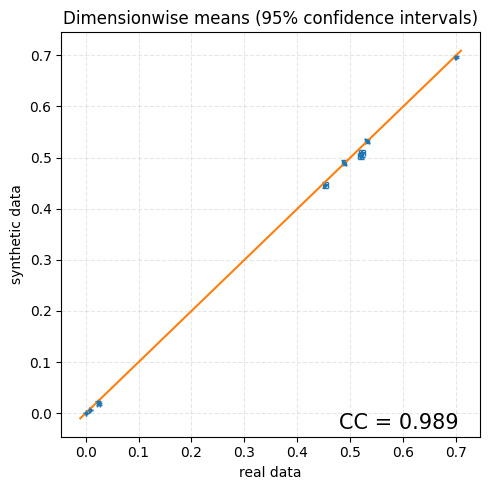

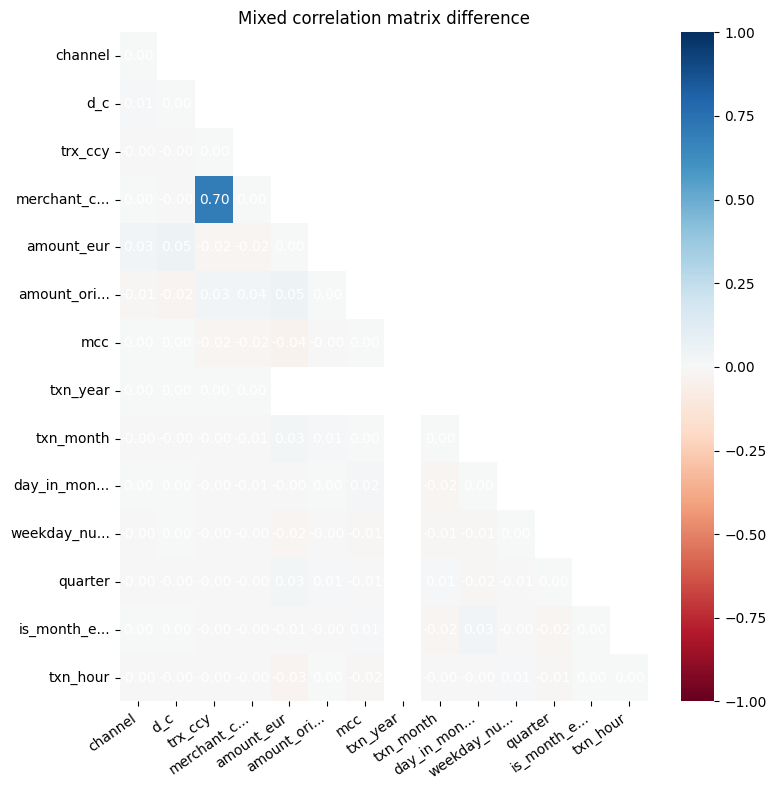

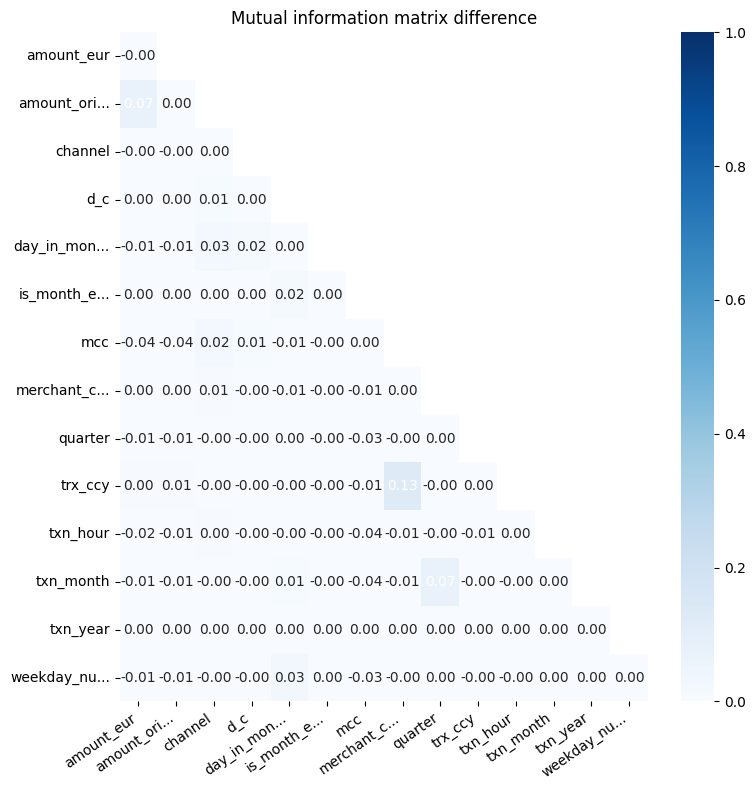

In [66]:
results_trx = run_syntheval(
    real_df=real_trx_original,
    synth_df=trx_synth_eval_processed,
    cat_cols=['channel', 'd_c', 'trx_ccy', 'merchant_country'],
    label='Transaction — Evaluation Run',
    holdout_df=trx_holdout_processed
)

## **P2.9 — Transaction Data: Synthetic Data Result**

*Build final synthetic transaction dataset with schema consistency.*


### **P2.9.1 — Transaction Data: Synthetic Data Result**

`build_final_trx_output()`
- reattaches `pseudo_customer_key`
- restores schema order
- prepares the dataset for downstream TO-BE simulation

> `pseudo_customer_key` is not learned by the model. It is reintroduced after generation as a linkage layer to preserve structural consistency.



In [67]:
def build_final_trx_output(df, pseudo_keys):
    df = df.copy()

    # attach pseudo customer key
    df['pseudo_customer_key'] = pseudo_keys.values

    # add synthetic txn_id
    df['txn_id'] = ['SYN_TXN_' + str(i).zfill(8) for i in range(len(df))]


    # reorder columns
    final_cols = [
        'txn_id',
        'pseudo_customer_key',
        'channel',
        'd_c',
        'trx_ccy',
        'amount_eur',
        'amount_orig',
        'mcc',
        'merchant_country',
        'txn_year',
        'txn_month',
        'day_in_month',
        'weekday_num',
        'quarter',
        'is_month_end',
        'txn_hour'
    ]

    final_cols = [c for c in final_cols if c in df.columns]
    df = df[final_cols]

    print('\n\033[1m----- FINAL SYNTHETIC TRANSACTION OUTPUT -----\033[0m')
    print(f'Shape   : {df.shape}')
    print(f'Columns : {df.columns.tolist()}')
    print(f'NaN     : {df.isnull().sum().sum()}')

    return df

In [68]:
trx_synth_final = build_final_trx_output(
    trx_synth_full_processed,
    pseudo_keys=trx_ready['pseudo_customer_key']
)


----- FINAL SYNTHETIC TRANSACTION OUTPUT -----
Shape   : (16797, 16)
Columns : ['txn_id', 'pseudo_customer_key', 'channel', 'd_c', 'trx_ccy', 'amount_eur', 'amount_orig', 'mcc', 'merchant_country', 'txn_year', 'txn_month', 'day_in_month', 'weekday_num', 'quarter', 'is_month_end', 'txn_hour']
NaN     : 7005


### **P2.9.2 — Transaction Data: Real Data Result**

`build_final_trx_baseline()`
- reattaches `pseudo_customer_key`
- reconstructs a schema-aligned real reference dataset for comparison


In [69]:
def build_final_transaction_baseline(df, original_keys):
    df = df.copy()

    # attach pseudo customer key
    df['pseudo_customer_key'] = original_keys.values

    # reorder columns
    final_cols = [
        'pseudo_customer_key',
        'channel',
        'd_c',
        'trx_ccy',
        'amount_eur',
        'amount_orig',
        'mcc',
        'merchant_country',
        'txn_year',
        'txn_month',
        'day_in_month',
        'weekday_num',
        'quarter',
        'is_month_end',
        'txn_hour'
    ]

    final_cols = [c for c in final_cols if c in df.columns]
    df = df[final_cols]

    return df

In [70]:
trx_real_final = build_final_transaction_baseline(
    real_trx_original,
    original_keys=trx_ready['pseudo_customer_key']
)

### **P2.9.3 — Transaction Data: Synthetic Data Final Result**

*The final synthetic transaction dataset is saved and compared against a schema-aligned real baseline.*

### **Transaction Variable Mapping**

| Stage                  | Evaluation                        | Production                          |
|-----------------------|----------------------------------|-------------------------------------|
| Model Input           | `trx_train_model`               | `trx_full_model_input`              |
| Real (Processed)      | `real_trx_original`             | `real_trx_original_full`            |
| Synthetic (Raw)       | `trx_synth_eval`                | `trx_synth_full`                    |
| Synthetic (Processed) | `trx_synth_eval_processed`      | `trx_synth_full_processed`          |
| Final Output          | —                                | `trx_synth_final`, `trx_real_final` |

> To avoid ambiguity, variables are explicitly separated between evaluation and production pipelines. This ensures that model validation and final data generation are not mixed.

In [71]:
print('Production check:')
print('trx_real_final exists :', 'trx_real_final' in globals())
print('trx_synth_final exists:', 'trx_synth_final' in globals())

Production check:
trx_real_final exists : True
trx_synth_final exists: True


In [72]:
output_path = r"data/synthetic_transactions.csv"
trx_synth_final.to_csv(output_path, index=False)

print('\n\033[1m----- PIPELINE 2 SAVED -----\033[0m')
print(f'Saved to: {output_path}')
print()

print('\n\033[1m[NOTE]\033[0m The real dataset shown here is a schema-aligned baseline. '
      'The original client_id has been replaced with pseudo_customer_key '
      'to ensure structural comparability with the synthetic dataset.')

print('\n\033[1m----- PRODUCTION MODE: TRANSACTION REAL DATA VS SYNTHETIC DATA -----\033[0m')

print('\n1. TRANSACTION REAL DATA')
print(f'Shape: {trx_real_final.shape}')
display(trx_real_final.head())

print('\n2. TRANSACTION SYNTHETIC DATA')
print(f'Shape: {trx_synth_final.shape}')
display(trx_synth_final.head())

print('\n[INFO] Both datasets share identical schema and are ready for downstream TO-BE simulation and cross-table integration.')


----- PIPELINE 2 SAVED -----
Saved to: D:/KULIAH/SEMESTER 4/DRAFT/Data Sources/seb_ee_synth_out/seb_ee_synth_out/final datasource/synthetic_transactions.csv


[NOTE] The real dataset shown here is a schema-aligned baseline. The original client_id has been replaced with pseudo_customer_key to ensure structural comparability with the synthetic dataset.

----- PRODUCTION MODE: TRANSACTION REAL DATA VS SYNTHETIC DATA -----

1. TRANSACTION REAL DATA
Shape: (16797, 15)


,pseudo_customer_key,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,SYN_C_000001,online,C,EUR,1485.08,1485.08,NaN,EE,2024,1,25,3,1,0,12
1,SYN_C_000001,online,D,EUR,75.08,75.08,NaN,EE,2024,1,12,4,1,0,18
2,SYN_C_000001,online,D,EUR,13.22,13.22,NaN,EE,2024,1,16,1,1,0,16
3,SYN_C_000001,card,D,EUR,11.05,11.05,5816.0,EE,2024,1,22,0,1,0,18
4,SYN_C_000001,online,D,EUR,16.07,16.07,NaN,EE,2024,1,18,3,1,0,15



2. TRANSACTION SYNTHETIC DATA
Shape: (16797, 16)


,txn_id,pseudo_customer_key,channel,d_c,trx_ccy,amount_eur,amount_orig,mcc,merchant_country,txn_year,txn_month,day_in_month,weekday_num,quarter,is_month_end,txn_hour
0,SYN_TXN_00000000,SYN_C_000001,card,D,EUR,2.36,2.36,7999.0,CH,2024,12,1,3,3,0,23
1,SYN_TXN_00000001,SYN_C_000001,card,D,EUR,10.22,10.58,5814.0,EE,2024,5,18,0,2,0,14
2,SYN_TXN_00000002,SYN_C_000001,online,C,EUR,392.60,367.53,NaN,EE,2024,6,23,3,2,0,18
3,SYN_TXN_00000003,SYN_C_000001,mobile,C,EUR,21.94,21.51,NaN,EE,2024,7,18,1,3,0,12
4,SYN_TXN_00000004,SYN_C_000001,online,C,EUR,2502.67,3252.47,NaN,EE,2024,8,21,3,3,0,23



[INFO] Both datasets share identical schema and are ready for downstream TO-BE simulation and cross-table integration.


---
## **Final Summary**

In [73]:
print('=' * 65)
print('SDG PIPELINE COMPLETE')
print('=' * 65)
print('Next step: TOBE_Simulation')
print('  Loads synthetic outputs above')
print('  Applies identical monitoring pipeline on synthetic data')


SDG PIPELINE COMPLETE
Next step: TOBE_Simulation
  Loads synthetic outputs above
  Applies identical monitoring pipeline on synthetic data
